In [1]:
import pandas as pd
import sqlite3

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')

    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']

    query = f"""
    SELECT 
        {', '.join(financial_indicators)} 
    FROM    
        balancetes_media_ano
    WHERE 
        cnpj IN (
            SELECT cnpj
            FROM balancetes_bancos_media_ano
            GROUP BY ano, cnpj
        );"""

    df = pd.read_sql_query(query, conn)

    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']

    for col in colunas_para_limpar:
        df[col] = (df[col]
                .str.lower()
                .str.normalize('NFD')
                .str.replace(r'[\u0300-\u036f]', '', regex=True))

    # Padronizando nomes
    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
    df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
    df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
    df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
    df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
    df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
    df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
    df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
    df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
    df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
    df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
    df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
    df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
    df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
    df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
    df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
    df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
    df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
    df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
    df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
    df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
    df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
    df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
    df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
    df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
    df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
    df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
    df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
    df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
    df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"

    # Conta duplicada
    df = df[df['conta'] != 88000008]
    df = df[df['conta'] != 47100004]
    df = df[df['conta'] != 51100007]
    df = df[df['conta'] != 78100004]
    df = df[df['conta'] != 61000001]

    mapa_contas = (
        df.groupby('conta')['nome_conta']
        .agg(lambda x: x.value_counts().index[0])
        .to_dict()
    )

    novo_mapeamento = {}

    for conta, nome in mapa_contas.items():
        conta_str = str(conta) # Garante que podemos verificar o início
        
        if conta_str.startswith('1'):
            novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'):
            novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'):
            novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'):
            novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'):
            novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'):
            novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'):
            novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'):
            novo_nome = f"compensacao passiva - {nome}"
        else:
            novo_nome = nome # Mantém o original se não houver regra
            
        novo_mapeamento[conta] = novo_nome

    mapa_contas = novo_mapeamento

    df = df.pivot(
        index=['ano', 'cnpj', 'nome', 'taxonomia'],
        columns='conta',
        values='saldo'
    ).reset_index()
    df['ano'] = df['ano'].astype(int)

    # Valor mínimo da conta operações de crédito
    df = df[df[16000001] > 1000000]
    #df = df[df['taxonomia'] != 'sociedade de credito ao microempreendedor']


    colunas_para_inverter = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia']]
    colunas_invertidas = []
        # Se o maior valor da coluna for 0 ou negativo, significa que toda a coluna é negativa
    for col in colunas_para_inverter:
        # Calcula o máximo e o mínimo ignorando os vazios explicitamente
        max_val = df[col].max(skipna=True)
        min_val = df[col].min(skipna=True)
        
        # REGRAS PARA INVERTER:
        # 1. pd.notna(max_val): Garante que a coluna não é 100% vazia
        # 2. max_val <= 0: Garante que não há números positivos
        # 3. min_val < 0: Garante que há valores negativos reais (ignora colunas só de Zeros/NaNs)
        
        if pd.notna(max_val) and (max_val <= 0) and (min_val < 0):
            df[col] = df[col] * -1
            colunas_invertidas.append(col)

    df.fillna(0, inplace=True)
    df_original = df.copy()

    # Dividindo os valores pelo Ativo Total (39999993)
    colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia', 39999993]]
    for col in colunas_a_dividir:
        df[col] = df[col] / df[39999993]
    df.drop(columns=[39999993, 99999995], inplace=True)
    df_filtrado = df.copy()

    df_original = df_original.rename(columns=novo_mapeamento)
    df = df.rename(columns=novo_mapeamento)
    return df, df_original, mapa_contas

df, df_original, mapa_contas = dados_bancos()


In [2]:
# Eliminando colunas esparsas

def eliminar_colunas_esparsas(df, df_original):
    # 1. Calcular a porcentagem de nulos em cada coluna
    #esparsidade = df.isnull().sum() / len(df)
    esparsidade = (df.isnull() | (df == 0)).sum() / len(df)
    # 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
    print(f"Colunas com > 10% de nulos: {sum(esparsidade > 0.10)}")
    print(f"Colunas com > 20% de nulos: {sum(esparsidade > 0.20)}")
    print(f"Colunas com > 30% de nulos: {sum(esparsidade > 0.30)}")
    print(f"Colunas com > 40% de nulos: {sum(esparsidade > 0.40)}")
    print(f"Colunas com > 50% de nulos: {sum(esparsidade > 0.50)}")

    # 3. Definir o limiar
    #limiar_corte = 0.30
    limiar_corte = 0.40

    # Identificar colunas a serem removidas
    colunas_para_remover = esparsidade[esparsidade > limiar_corte].index
    colunas_para_remover = [col for col in colunas_para_remover if col not in ['ano', 'cnpj', 'nome']]
    # 4. Criar o novo dataset filtrado
    df_filtrado = df.drop(columns=colunas_para_remover)
    df_original = df_original.drop(columns=colunas_para_remover)

    print(f"\nDimensão original: {df.shape[1]} colunas")
    print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
    df_filtrado.fillna(0, inplace=True)
    return df_filtrado, df_original

df_filtrado, df_original = eliminar_colunas_esparsas(df, df_original)

Colunas com > 10% de nulos: 156
Colunas com > 20% de nulos: 144
Colunas com > 30% de nulos: 133
Colunas com > 40% de nulos: 114
Colunas com > 50% de nulos: 103

Dimensão original: 201 colunas
Dimensão após corte de esparsidade: 87 colunas


Redução de dimensionalidade

In [3]:
# Análise de Correlação para Identificar Variáveis Redundantes
import numpy as np
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import RobustScaler
import seaborn as sns

def remover_colunas_redundantes(df_filtrado):
    X = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'], axis=1)
    # 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
    corr_matrix = X.corr(method='pearson')
    corr_matrix_abs = corr_matrix.abs()

    # 2. Selecionar apenas o triângulo superior da matriz
    # Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

    # 3. Definir o Limiar de Corte (Threshold)
    # 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
    threshold = 0.95

    # Encontrar colunas que têm correlação > threshold com qualquer outra coluna
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
    print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
    print(to_drop)

    # Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
    df_filtrado.drop(columns=to_drop, inplace=True)
    X.drop(columns=to_drop, inplace=True)

    scaler = StandardScaler()
    #scaler = RobustScaler()
    X.columns = X.columns.astype(str)
    #colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
    #df_identificadores = df_filtrado[colunas_id]
    #X = df_filtrado.drop(columns=colunas_id, axis=1)
    X_scaled = scaler.fit_transform(X)
    return X, df_filtrado

X, df_filtrado = remover_colunas_redundantes(df_filtrado)


--- Contas Redundantes a Descartar (Correlação > 0.95) ---
Número de variáveis sugeridas para remoção: 17
['ativo realizavel - outros valores e bens', 'ativo realizavel - outros valores e bens', 'ativo permanente - ativos intangiveis', 'compensacao ativa - titulos e valores mobiliarios', 'resultado credor - receitas operacionais', 'resultado devedor - (-) resultado devedor', 'resultado devedor - (-) despesas operacionais', 'resultado devedor - (-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos', 'resultado devedor - (-) imposto de renda', 'compensacao passiva - compensacao passiva', 'compensacao passiva - coobrigacoes e riscos em garantias prestadas', 'compensacao passiva - titulos e valores mobiliarios', 'compensacao passiva - custodia de valores', 'compensacao passiva - cobranca', 'compensacao passiva - controle', 'compensacao passiva - classificacao da carteira de creditos', 'compensacao passiva - operacoes de creditos e arrendamento mercantil']


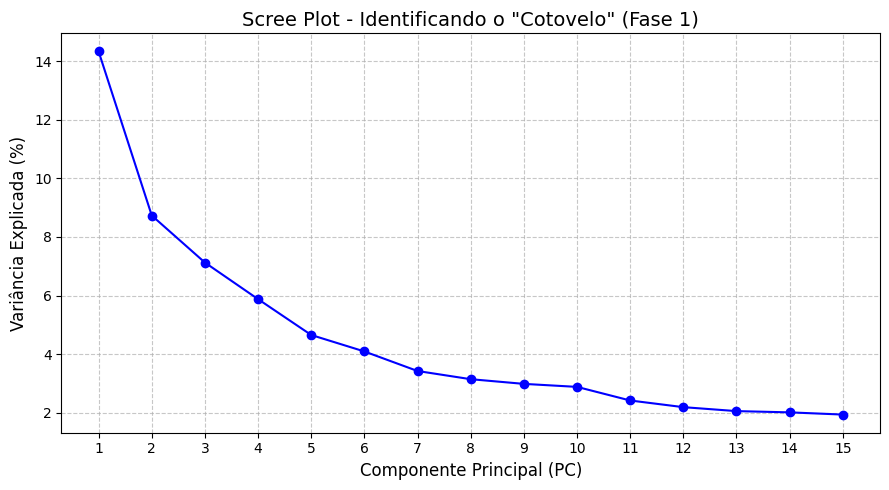

In [4]:
#Primeira aplicação do PCA para identificar os outliers

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def aplicar_pca_diagnostico(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # 1. Rodamos o PCA com os primeiros 15 componentes apenas para ver a curva de queda
    pca_diagnostico = PCA(n_components=15, random_state=42)
    pca_diagnostico.fit(X_scaled)

    # 2. Extraímos a variância INDIVIDUAL de cada componente (em porcentagem)
    variancia_individual = pca_diagnostico.explained_variance_ratio_ * 100

    # 3. Desenhamos o Gráfico de Cotovelo
    plt.figure(figsize=(9, 5))
    plt.plot(range(1, 16), variancia_individual, marker='o', linestyle='-', color='b')

    plt.title('Scree Plot - Identificando o "Cotovelo" (Fase 1)', fontsize=14)
    plt.xlabel('Componente Principal (PC)', fontsize=12)
    plt.ylabel('Variância Explicada (%)', fontsize=12)
    plt.xticks(range(1, 16)) # Garante que todos os números de 1 a 15 apareçam no eixo X
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

aplicar_pca_diagnostico(X)

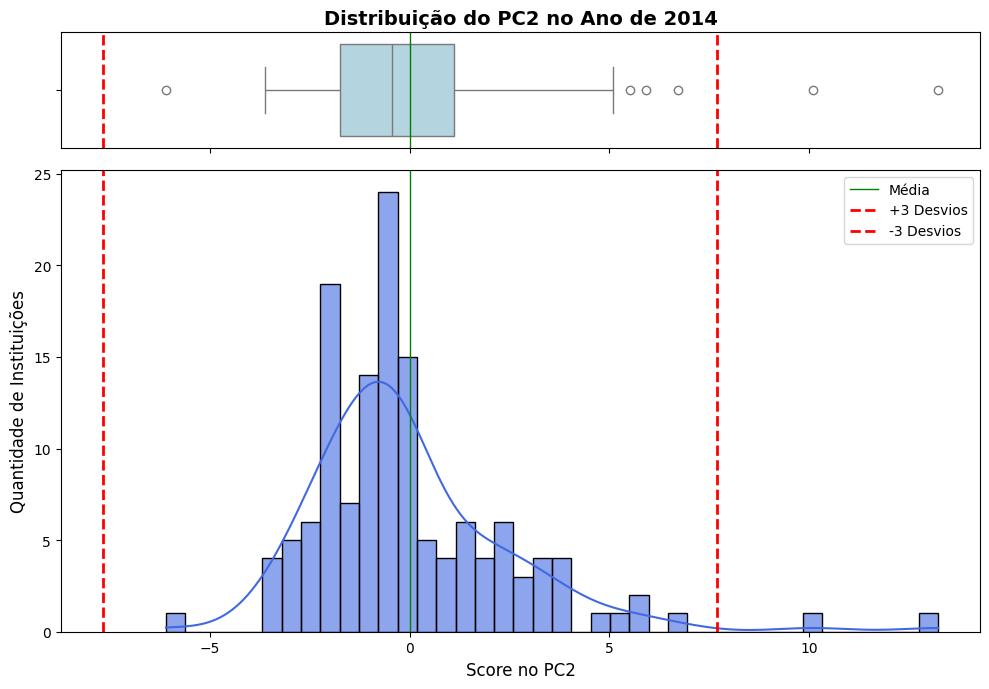

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def visualizar_distribuicao_pc(df_completo, ano_alvo, pc_alvo=1, limite_desvios=4):
    """
    Gera um gráfico duplo (Boxplot + Histograma) para visualizar a distribuição
    dos dados em um Componente Principal específico de um ano determinado.
    """
    
    # 1. Filtra a base completa apenas para o ano escolhido
    df_ano = df_completo[df_completo['ano'] == ano_alvo]
    
    if df_ano.empty:
        print(f"Sem dados para o ano {ano_alvo}.")
        return
        
    # 2. Cria o 'X_ano' separando as colunas de identificação na hora
    colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia', 'taxonomia_agrupada']
    X_ano = df_ano.drop(columns=colunas_id, errors='ignore')
    
    # 3. Matemática (Padronização + PCA) para este ano específico
    scaler = StandardScaler()
    X_ano_scaled = scaler.fit_transform(X_ano)
    
    pca = PCA(n_components=pc_alvo, random_state=42)
    pca_array = pca.fit_transform(X_ano_scaled)
    
    # Isola os dados apenas do componente que queremos desenhar (índice começa em 0)
    dados_pc = pca_array[:, pc_alvo - 1]
    
    # 4. Calcular Média e as linhas de corte do Z-score
    media = np.mean(dados_pc)
    desvio_padrao = np.std(dados_pc)
    corte_superior = media + (limite_desvios * desvio_padrao)
    corte_inferior = media - (limite_desvios * desvio_padrao)
    
    # 5. Configurar a figura com 2 gráficos empilhados
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, 
        figsize=(10, 7), 
        sharex=True, 
        gridspec_kw={'height_ratios': [1, 4]}
    )
    
    # --- Gráfico Superior: Boxplot ---
    sns.boxplot(x=dados_pc, ax=ax_box, color='lightblue', fliersize=6)
    ax_box.set_title(f'Distribuição do PC{pc_alvo} no Ano de {ano_alvo}', fontsize=14, fontweight='bold')
    ax_box.set_xlabel('')
    
    # --- Gráfico Inferior: Histograma ---
    sns.histplot(x=dados_pc, ax=ax_hist, kde=True, bins=40, color='royalblue', alpha=0.6)
    ax_hist.set_ylabel('Quantidade de Instituições', fontsize=12)
    ax_hist.set_xlabel(f'Score no PC{pc_alvo}', fontsize=12)
    
    # 6. Traçar as Linhas de Corte do Z-Score
    for ax in [ax_box, ax_hist]:
        ax.axvline(media, color='green', linestyle='-', linewidth=1, label='Média')
        ax.axvline(corte_superior, color='red', linestyle='--', linewidth=2, label=f'+{limite_desvios} Desvios')
        ax.axvline(corte_inferior, color='red', linestyle='--', linewidth=2, label=f'-{limite_desvios} Desvios')
        
    ax_hist.legend()
    plt.tight_layout()
    plt.show()

visualizar_distribuicao_pc(df_filtrado, ano_alvo= 2014, pc_alvo=2, limite_desvios=3)

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def remover_outliers_por_ano(df_original, df_filtrado, X, limite_desvios, n_componentes_fase1):
    # 1. Separar os identificadores e a matriz numérica (X)
    colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']

    # Isola os identificadores para guardarmos
    df_identificadores = df_filtrado[colunas_id]


    bancos_normais_list = []
    bancos_outliers_list = []
    historico_variancia = []

    # 2. Iniciar a "Máquina do Tempo" (Loop ano a ano)
    for ano_atual in df_identificadores['ano'].unique():
        
        # Filtrar o ano atual tanto na matriz X quanto nos identificadores
        mascara_ano = (df_identificadores['ano'] == ano_atual)
        X_ano = X[mascara_ano]
        id_ano = df_identificadores[mascara_ano]
        
        # Se por acaso algum ano não tiver dados, pula para o próximo
        if X_ano.empty:
            continue
            
        # Padronizar os dados EXCLUSIVAMENTE com a média deste ano
        scaler_ano = StandardScaler()
        X_ano_padronizado = scaler_ano.fit_transform(X_ano)
        
        # Rodar o PCA diagnóstico para este ano
        pca_ano = PCA(n_components=n_componentes_fase1, random_state=42)
        pca_array_ano = pca_ano.fit_transform(X_ano_padronizado)
        df_pca_ano = pd.DataFrame(pca_array_ano, index=X_ano.index)

        variancia_percentual = pca_ano.explained_variance_ratio_ * 100
        
        # Salvar os dados deste ano no nosso rastreador
        historico_variancia.append({
            'Ano': ano_atual,
            'PC1 (%)': np.round(variancia_percentual[0], 2),
            'PC2 (%)': np.round(variancia_percentual[1], 2),
            'PC3 (%)': np.round(variancia_percentual[2], 2),
            #'PC4 (%)': np.round(variancia_percentual[3], 2),
            'Acumulada Fase 1 (%)': np.round(np.sum(variancia_percentual), 2)
        })
        
        # Calcular o Z-score e achar os outliers deste ano específico
        z_scores_ano = np.abs((df_pca_ano - df_pca_ano.mean()) / df_pca_ano.std())
        mascara_outliers_ano = (z_scores_ano > limite_desvios).any(axis=1)
        
        # Reconstruir o dataframe do ano (colando as IDs de volta no X original)
        df_completo_ano = pd.concat([id_ano, X_ano], axis=1)
        
        # Separar os normais das anomalias
        outliers_do_ano = df_completo_ano[mascara_outliers_ano]
        normais_do_ano = df_completo_ano[~mascara_outliers_ano]
        
        # Guardar os resultados do ano nas listas
        bancos_outliers_list.append(outliers_do_ano)
        bancos_normais_list.append(normais_do_ano)

    # 3. Costurar o resultado final
    df_outliers_final = pd.concat(bancos_outliers_list)
    df_normais_final = pd.concat(bancos_normais_list)

    df_filtrado = df_normais_final
    colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
    df_identificadores = df_filtrado[colunas_id]
    X = df_filtrado.drop(columns=colunas_id, axis=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    df_original = df_original.loc[df_original.index.isin(df_filtrado.index)]

    df_variancia_historica = pd.DataFrame(historico_variancia).sort_values('Ano').reset_index(drop=True)

    print("--- Evolução da Variância Explicada no SFN (Ano a Ano) ---")
    print(df_variancia_historica.to_string())
    return df_original, df_filtrado, X

# Parâmetros da Fase 1 (Ajuste os desvios e componentes conforme o seu Scree Plot)

df_original, df_filtrado , X= remover_outliers_por_ano(df_original, df_filtrado, X, limite_desvios = 3, n_componentes_fase1 = 3)

--- Evolução da Variância Explicada no SFN (Ano a Ano) ---
     Ano  PC1 (%)  PC2 (%)  PC3 (%)  Acumulada Fase 1 (%)
0   2010    16.08    10.34     9.10                 35.52
1   2011    16.28    11.29     9.50                 37.07
2   2012    17.34    10.92     9.01                 37.27
3   2013    15.64    10.53     7.79                 33.96
4   2014    15.83     9.95     7.03                 32.81
5   2015    15.93    10.07     6.99                 32.99
6   2016    14.56    10.29     7.21                 32.06
7   2017    14.46    10.15     7.35                 31.96
8   2018    15.87     9.38     7.15                 32.40
9   2019    17.48     8.56     7.44                 33.47
10  2020    16.50     8.45     8.39                 33.33
11  2021    16.40     8.99     7.97                 33.36
12  2022    17.66    10.24     8.63                 36.52
13  2023    15.86     9.47     8.53                 33.86
14  2024    16.97     9.87     8.46                 35.30


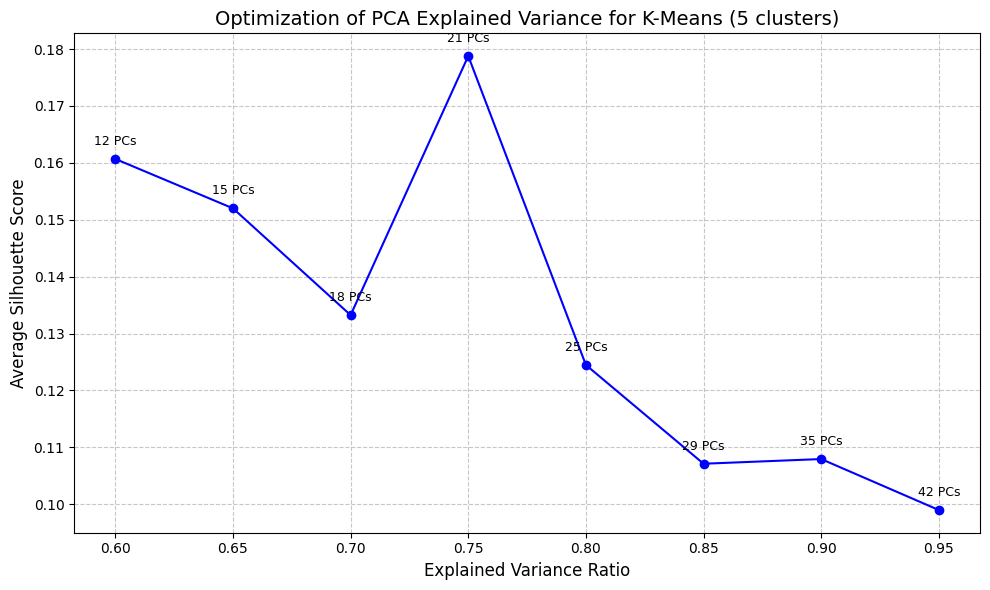

In [7]:
# Análise de Silhueta x Variância do PCA para Otimizar o K-Means

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def otimizar_pca_para_kmeans(X, numero_de_clusters):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # 1. Definimos a grade de variâncias que queremos testar (de 60% a 95%, pulando de 5 em 5)
    niveis_variancia = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

    # Listas vazias para guardar os resultados
    escores_silhueta = []
    qnt_componentes = []

    # 2. O Loop de Experimentação
    for var in niveis_variancia:
        # A. Roda o PCA para o nível de variância atual da repetição
        pca_test_silhoutte = PCA(n_components=var, random_state=42)
        dados_pca = pca_test_silhoutte.fit_transform(X_scaled)
        
        # Guarda quantos componentes o PCA precisou para atingir essa variância
        qnt_componentes.append(pca_test_silhoutte.n_components_)
        
        # B. Roda o K-Means nos dados reduzidos
        kmeans = KMeans(n_clusters=numero_de_clusters, random_state=42)
        kmeans.fit(dados_pca)
        
        # C. Calcula e guarda o Escore de Silhueta
        score = silhouette_score(dados_pca, kmeans.labels_)
        escores_silhueta.append(score)

    # 3. Visualizando os Resultados
    plt.figure(figsize=(10, 6))

    # Plota a linha principal (Variância vs Silhueta)
    plt.plot(niveis_variancia, escores_silhueta, marker='o', linestyle='-', color='b')

    # Adiciona o número de componentes como rótulo em cada ponto para facilitar sua vida
    for i, txt in enumerate(qnt_componentes):
        plt.annotate(f"{txt} PCs", (niveis_variancia[i], escores_silhueta[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    plt.title(f'Optimization of PCA Explained Variance for K-Means ({numero_de_clusters} clusters)', fontsize=14)
    plt.xlabel('Explained Variance Ratio', fontsize=12)
    plt.ylabel('Average Silhouette Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

numero_de_clusters = 5
otimizar_pca_para_kmeans(X, numero_de_clusters)

In [8]:
# Criação do PCA Final com o Número de Componentes Otimizado

def calcular_pca_final(X, num_componentes_pca):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca_final = PCA(n_components=num_componentes_pca) # num de componentes do PCA
    X_pca = pca_final.fit_transform(X_scaled)

    features = X.columns.tolist()

    # Criar um DataFrame com os componentes principais de cada instituição
    # Gerar dinamicamente os nomes das colunas: 'PC1', 'PC2', 'PC3', etc.
    nomes_componentes = [f'PC{i+1}' for i in range(X_pca.shape[1])]

    # Converter o array do PCA de volta para DataFrame do Pandas
    df_pca_puro = pd.DataFrame(
        X_pca, 
        columns=nomes_componentes, 
        index=df_filtrado.index # Mantém a mesma ordem das linhas original
    )
    df_var_pca = df_pca_puro.var()

    # Colar os identificadores ao lado dos componentes
    df_pca_valores = pd.concat([df_filtrado[['ano', 'cnpj', 'nome']], df_pca_puro], axis=1)

    # Criar um DataFrame com os pesos (Loadings)
    loadings = pd.DataFrame(
        pca_final.components_.T, 
        columns=[f'PC{i+1}' for i in range(num_componentes_pca)], 
        index=features
    )
    # Análise de Relevância dos Componentes do PCA
    # 1. Extrair a porcentagem de relevância de CADA componente do PCA
    relevancia_individual = pca_final.explained_variance_ratio_

    # 2. Calcular a relevância ACUMULADA (soma progressiva)
    relevancia_acumulada = np.cumsum(relevancia_individual)

    # 3. Criar uma tabela para visualizar (DataFrame Pandas)
    pca_relevancia = pd.DataFrame({
        'Componente': [f'PC{i+1}' for i in range(len(relevancia_individual))],
        'Variância Individual (%)': np.round(relevancia_individual * 100, 2),
        'Variância Acumulada (%)': np.round(relevancia_acumulada * 100, 2)
    })
    return X_pca, df_pca_valores, loadings, pca_relevancia

num_componentes_pca = 25
X_pca, df_pca_valores, loadings, pca_relevancia = calcular_pca_final(X, num_componentes_pca)

Criação e análises dos cluters

In [9]:
#Criação do modelo final de K-Means com o número de clusters otimizado

def criar_modelo_kmeans_final(X_pca, numero_de_clusters, df_filtrado, df_original):
    # Initialize and train the final model
    final_kmeans = KMeans(n_clusters=numero_de_clusters, init='k-means++', random_state=42, n_init='auto')
    final_kmeans.fit(X_pca)

    # Get the cluster labels for each bank
    cluster_labels = final_kmeans.labels_

    # Add the cluster labels to the original DataFrame
    df_filtrado['Cluster'] = cluster_labels
    df_filtrado.columns = df_filtrado.columns.astype(str)
    coluna_para_mover = df_filtrado.pop('Cluster')
    df_filtrado.insert(4, 'Cluster', coluna_para_mover)

    df_original['Cluster'] = cluster_labels
    df_original.columns = df_original.columns.astype(str)
    coluna_para_mover = df_original.pop('Cluster')
    df_original.insert(4, 'Cluster', coluna_para_mover) 

    # Save the results to a new CSV or update the SQLite database
    df_filtrado[['cnpj', 'Cluster']].to_csv('bank_clusters.csv', index=False)

    # Profile the clusters by calculating the mean of the original (unscaled) features for each cluster
    cluster_profiles = df_filtrado.groupby('Cluster')[X.columns].mean().sort_values(by='ativo realizavel - operacoes de credito', ascending=False)
#    cluster_profiles.to_csv('cluster_profiles.csv', index=False)
    return df_filtrado, df_original, final_kmeans, cluster_profiles

df_filtrado, df_original, final_kmeans, cluster_profiles = criar_modelo_kmeans_final(X_pca, numero_de_clusters, df_filtrado, df_original)

                                    Variavel_Original  Estatistica_H  \
0                 ativo realizavel - ativo realizavel    1806.233814   
9             ativo realizavel - operacoes de credito    1496.581989   
12  ativo realizavel - (-) provisoes para operacoe...    1455.873570   
29     compensacao ativa - operacoes de risco nivel a    1470.695260   
27  compensacao ativa - classificacao da carteira ...    1884.986099   
48  resultado credor - rendas de operacoes de credito    1758.443800   
55  resultado devedor - (-) aprovisionamentos e aj...    1288.429797   
37                passivo exigivel - passivo exigivel    1267.804500   
34     compensacao ativa - operacoes de risco nivel f    1209.197803   
35     compensacao ativa - operacoes de risco nivel g    1204.899834   

          P-Valor  
0    0.000000e+00  
9    0.000000e+00  
12   0.000000e+00  
29   0.000000e+00  
27   0.000000e+00  
48   0.000000e+00  
55  1.073319e-277  
37  3.180224e-273  
34  1.615171e-260  
35  1.3

/tmp/ipykernel_1463184/1600968790.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')
/tmp/ipykernel_1463184/1600968790.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')


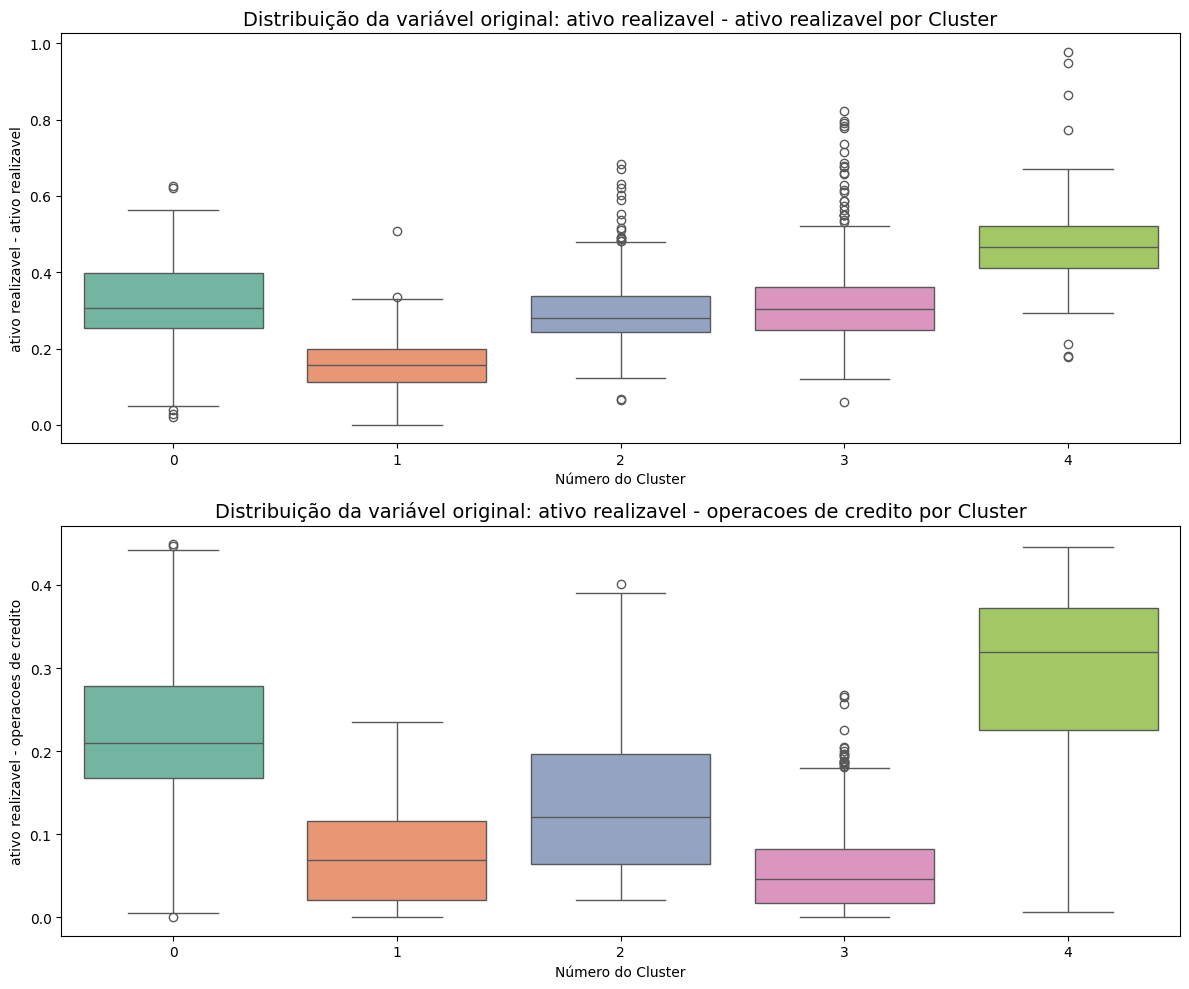

In [10]:
# Teste Kruskal-Wallis (não assume normalidade dos dados)

from scipy.stats import kruskal

def calcular_kruskal_clusters(clusters, coluna_cluster):
    resultados = []
    
    # Seleciona apenas variáveis numéricas (ignorando a coluna do cluster)
    colunas_numericas = clusters.select_dtypes(include=['float64', 'int64']).columns
    colunas_numericas = [col for col in colunas_numericas if col != coluna_cluster]
    
    for coluna in colunas_numericas:
        # Separa a variável em listas, uma para cada cluster, removendo os NaNs
        grupos = [grupo[coluna].dropna() for nome, grupo in clusters.groupby(coluna_cluster)]
        
        # Como o Kruskal exige pelo menos 2 grupos com dados, fazemos uma checagem
        if len(grupos) > 1:
            stat, p_valor = kruskal(*grupos)
            
            resultados.append({
                'Variavel_Original': coluna,
                'Estatistica_H': stat,
                'P-Valor': p_valor
            })
            
    # Converte para DataFrame e ordena pelas variáveis mais significantes (menor p-valor)
    df_resultados = pd.DataFrame(resultados).sort_values(by='P-Valor')
    
    return df_resultados


# Vamos supor que o teste de Kruskal revelou que 'iip' e 'reser' são as melhores variáveis.
def plotar_boxplots_por_cluster(clusters):
    variaveis_top = ['ativo realizavel - ativo realizavel', 'ativo realizavel - operacoes de credito'] # Substitua pelas variáveis do topo da sua tabela

    # Configura o tamanho da figura para caber vários gráficos
    plt.figure(figsize=(12, 5 * len(variaveis_top)))

    for i, variavel in enumerate(variaveis_top):
        plt.subplot(len(variaveis_top), 1, i+1)
        
        # Plota o boxplot
        sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')
        
        plt.title(f'Distribuição da variável original: {variavel} por Cluster', fontsize=14)
        plt.ylabel(variavel)
        plt.xlabel('Número do Cluster')

    plt.tight_layout()
    plt.show()

df_filtrado_clusters_fixos =  df_filtrado.copy(deep=True)
df_filtrado_clusters_fixos['Cluster'] = df_filtrado_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

clusters = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'])
clusters_fixos = df_filtrado_clusters_fixos.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'])

kruskal = calcular_kruskal_clusters(clusters, 'Cluster')
print(kruskal.head(10))
plotar_boxplots_por_cluster(df_filtrado)

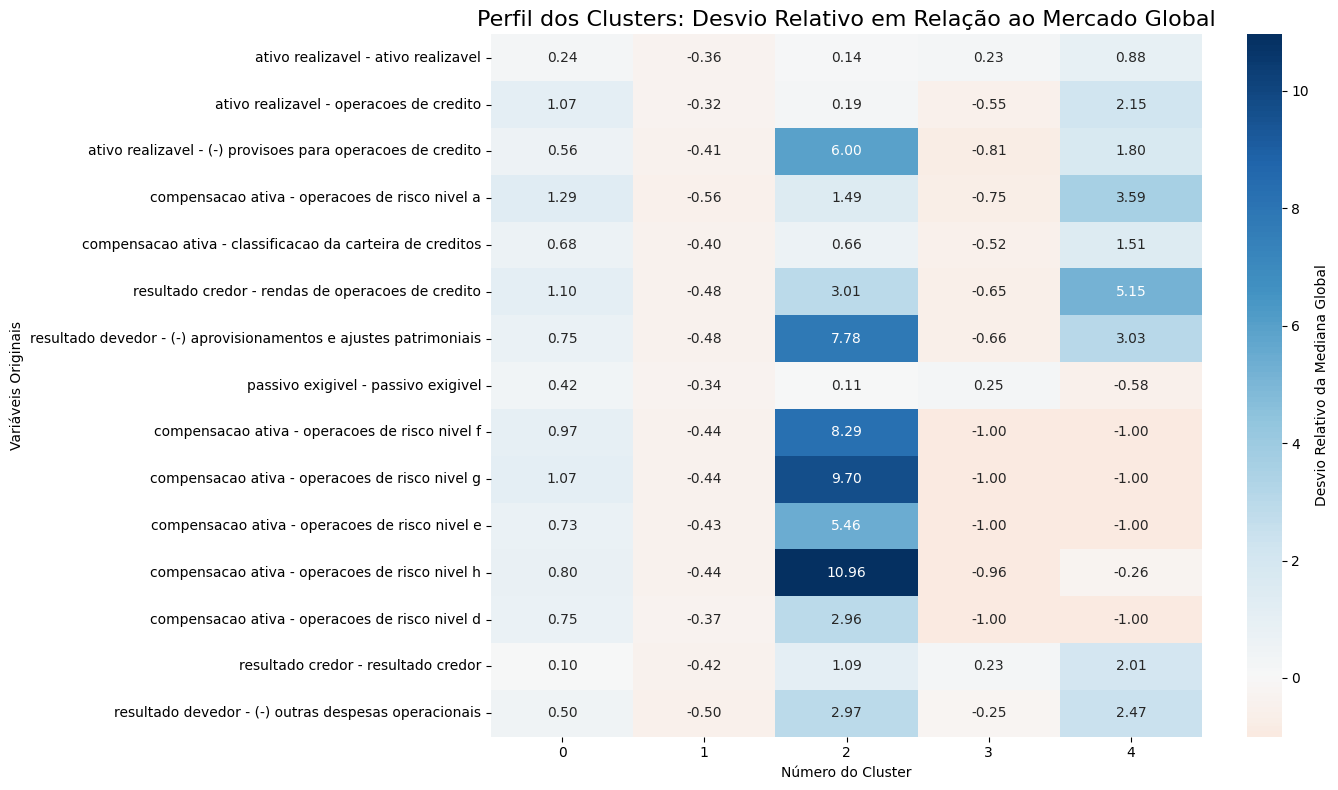

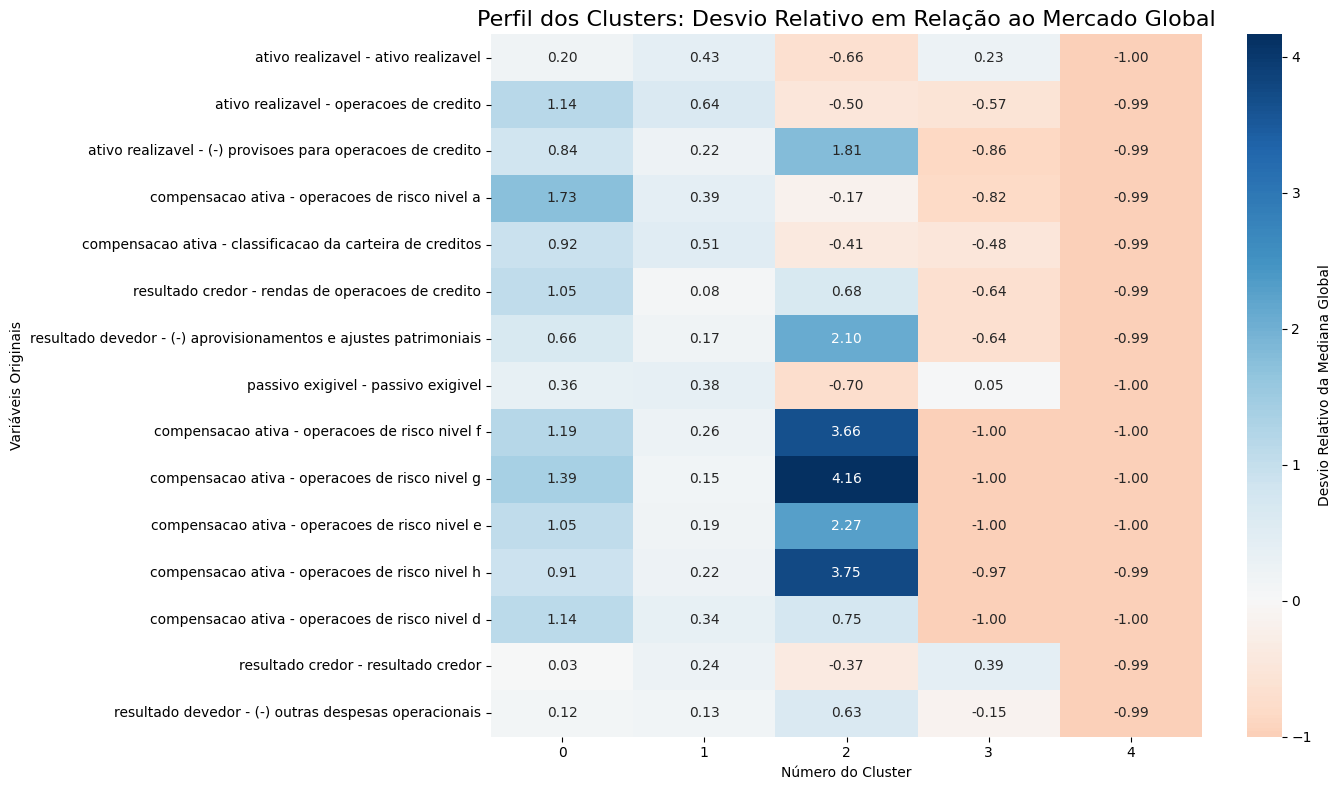

In [11]:
# Criando o Heatmap de Perfil dos Clusters com as Variáveis Originais

def plotar_heatmap_perfil_clusters(clusters, kruskal):
    clusters_filtrado = clusters.copy()
#    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 0]
#    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 1]
#    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 2]
#    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 3]
#    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 4]

    # 1. Pegue as 15 variáveis mais importantes do seu teste de Kruskal-Wallis
    # (Assumindo que df_importancia é o resultado do código anterior)
    top_15_variaveis = kruskal['Variavel_Original'].head(15).tolist()

    colunas_invertidas = []
    for col in top_15_variaveis:
        # Se o maior valor da coluna for 0 ou negativo, significa que toda a coluna é negativa
        if clusters_filtrado[col].max() <= 0:
            clusters_filtrado[col] = clusters_filtrado[col] * -1
            colunas_invertidas.append(col)

    # 2. Calcule a mediana global para essas 15 variáveis
    mediana_global = clusters_filtrado[top_15_variaveis].median()

    # 3. Calcule a mediana de cada cluster para essas 15 variáveis
    mediana_clusters = clusters_filtrado.groupby('Cluster')[top_15_variaveis].median()

    # 4. Calcule a variação percentual (ou relativa) do cluster vs o global
    # Isso normaliza os dados para o gráfico: 0 = igual ao global, > 0 acima, < 0 abaixo
    desvio_relativo = (mediana_clusters - mediana_global) / mediana_global.abs().replace(0, 1e-9) # Evita divisão por zero

    # 5. Plota o Heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(desvio_relativo.T, # Transposto para variáveis ficarem nas linhas
                cmap='RdBu',       # Vermelho para abaixo da média, Azul para acima
                center=0,          # O branco será exatamente a média global
                annot=True,        # Mostra os números no gráfico
                fmt=".2f",         # 2 casas decimais
                cbar_kws={'label': 'Desvio Relativo da Mediana Global'})

    plt.title('Perfil dos Clusters: Desvio Relativo em Relação ao Mercado Global', fontsize=16)
    plt.xlabel('Número do Cluster')
    plt.ylabel('Variáveis Originais')
    plt.tight_layout()
    plt.show()


plotar_heatmap_perfil_clusters(df_filtrado, kruskal)
#plotar_heatmap_perfil_clusters(df_filtrado_clusters_fixos, kruskal)
plotar_heatmap_perfil_clusters(df_original, kruskal)

In [12]:
# Teste de hipótese para comparar contas entre clusters usando o Teste T de Welch e o Teste de Mann-Whitney

import scipy.stats as stats

def teste_t_mannwhitney_clusters(df_filtrado, c1, c2, conta):

    # Separar as amostras dos dois clusters
    grupo_c0 = df_filtrado[df_filtrado['Cluster'] == c1][conta]
    grupo_c2 = df_filtrado[df_filtrado['Cluster'] == c2][conta]

    print(f"Tamanho da Amostra C0: {len(grupo_c0)} | Média: {grupo_c0.mean():.4f}")
    print(f"Tamanho da Amostra C2: {len(grupo_c2)} | Média: {grupo_c2.mean():.4f}\n")

    # Teste T de Welch (Hipótese Alternativa: C2 é MAIOR que C0)
    t_stat, p_val_t = stats.ttest_ind(grupo_c2, grupo_c0, equal_var=False, alternative='greater')

    print("=== Teste T de Welch (Paramétrico) ===")
    print(f"Estatística T: {t_stat:.4f}")
    print(f"P-valor:       {p_val_t:.4e}")
    if p_val_t < 0.05:
        print(f"Conclusão: Rejeitamos H0. A proporção de crédito no Cluster {c2} é ESTATISTICAMENTE MAIOR que no Cluster {c1}.\n")
    else:
        print(f"Conclusão: Não podemos afirmar que o Cluster {c2} é maior.\n")

    # Teste de Mann-Whitney (Não-Paramétrico)
    u_stat, p_val_u = stats.mannwhitneyu(grupo_c2, grupo_c0, alternative='greater')

    print("=== Teste U de Mann-Whitney (Não-Paramétrico) ===")
    print(f"Estatística U: {u_stat:.4f}")
    print(f"P-valor:       {p_val_u:.4e}")
    if p_val_u < 0.05:
        print(f"Conclusão: Rejeitamos H0. A mediana da conta no Cluster {c2} é ESTATISTICAMENTE MAIOR que no Cluster {c1}.")
    else:
        print(f"Conclusão: Não podemos afirmar que a mediana de {c2} é maior.")

def plotar_distribuicao_por_cluster(df_teste, c1, c2, conta):
    df_plot = df_teste[df_teste['Cluster'].isin([c1, c2])].copy()

    df_plot['Cluster'] = df_plot['Cluster'].astype(str)

    # Configurar o estilo visual acadêmico do gráfico
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # ==========================================
    # GRÁFICO 1: Histograma + Curva de Densidade (KDE)
    # ==========================================
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_plot, 
        x=conta, 
        hue='Cluster',
        hue_order=[str(c1), str(c2)],
        kde=True,               # Adiciona a linha suave (KDE) para ver a normalidade
        stat='density',         # Normaliza o eixo Y para comparar grupos de tamanhos diferentes
        common_norm=False,      # Calcula a densidade separadamente para C0 e C2
        palette=['#1f77b4', '#d62728'], # Cores clássicas (Azul e Vermelho)
        alpha=0.4,              # Transparência
        bins=30                 # Quantidade de barras
    )

    plt.title(f'Distribuição {conta} (Cluster {c1} vs {c2})', fontsize=14, weight='bold')
    plt.xlabel(f'{conta}', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)

    plt.tight_layout()
    plt.show()


Tamanho da Amostra C0: 775 | Média: -3.2380
Tamanho da Amostra C2: 109 | Média: -3.0611

=== Teste T de Welch (Paramétrico) ===
Estatística T: 1.4400
P-valor:       7.6222e-02
Conclusão: Não podemos afirmar que o Cluster 4 é maior.

=== Teste U de Mann-Whitney (Não-Paramétrico) ===
Estatística U: 47160.0000
P-valor:       2.4308e-02
Conclusão: Rejeitamos H0. A mediana da conta no Cluster 4 é ESTATISTICAMENTE MAIOR que no Cluster 0.


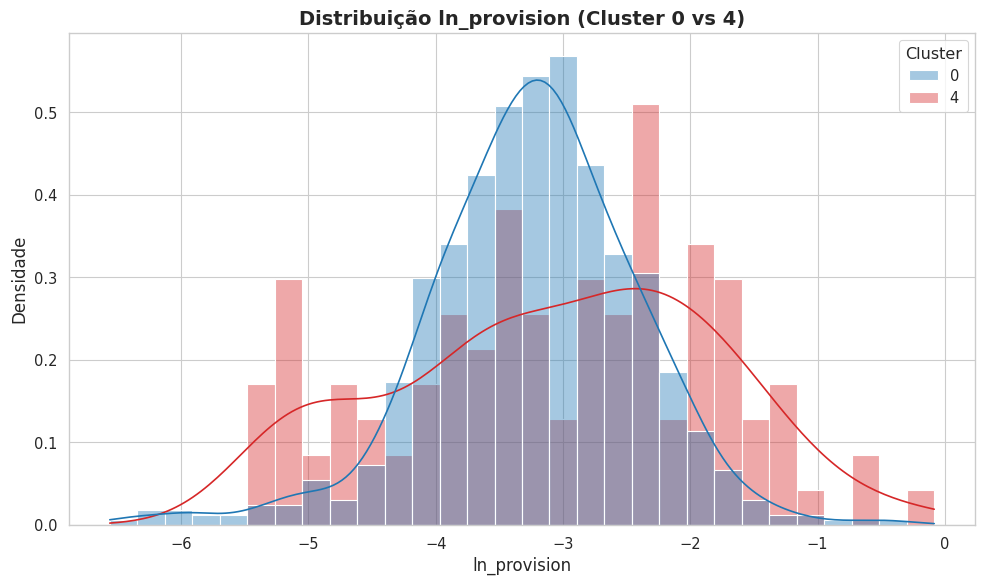

In [13]:

def comparar_clusters(df_original, c1, c2, conta):
    teste_t_mannwhitney_clusters(df_original, c1, c2, conta)
    plotar_distribuicao_por_cluster(df_original, c1, c2, conta)

df_original['provision'] = df_original['ativo realizavel - (-) provisoes para operacoes de credito']/df_original['ativo realizavel - operacoes de credito']
df_original['ln_provision'] = np.log(df_original['provision'] + 1e-6)

comparar_clusters(df_original, c1=0, c2=4, conta='ln_provision')
# Cluster4 é o mais agressivo (maior proporção de crédito em relação ao total do ativo realizável), Cluster1 é o segundo mais agressivo. Clusters 0 e 2 são mais conservadores.

Tamanho da Amostra C0: 109 | Média: 0.2929
Tamanho da Amostra C2: 373 | Média: 0.1400

=== Teste T de Welch (Paramétrico) ===
Estatística T: -13.9714
P-valor:       1.0000e+00
Conclusão: Não podemos afirmar que o Cluster 2 é maior.

=== Teste U de Mann-Whitney (Não-Paramétrico) ===
Estatística U: 5808.0000
P-valor:       1.0000e+00
Conclusão: Não podemos afirmar que a mediana de 2 é maior.


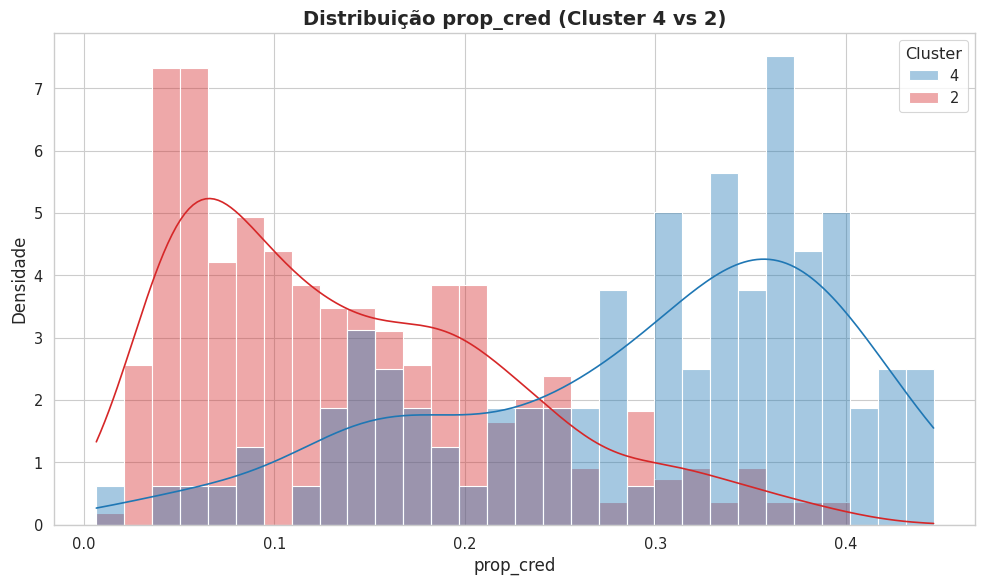

In [14]:

#df_original['ln_ativo'] = np.log(df_original['compensacao ativa - total geral do ativo'] + 1e-6)

#comparar_clusters(df_original, c1=4, c2=1, conta='ln_ativo')

# O Ativo Total do Cluster 0 é o mais alto dos clusters, seguido pelo Cluster 2, 1 e 4. No entando, a diferença entre os clusters 2, 3 e 4 é pequena.

df_original['prop_cred'] = df_original['ativo realizavel - operacoes de credito'] / df_original['compensacao ativa - total geral do ativo']
#df_original['prop_arrendamento'] = df_original['ativo realizavel - operacoes de arrendamento mercantil'] / df_original['compensacao ativa - classificacao da carteira de creditos']
df_original['prop_outros_creditos'] = df_original['ativo realizavel - outros creditos'] / df_original['compensacao ativa - classificacao da carteira de creditos']
df_original['ln_prop_cred'] = np.log(df_original['prop_cred'] + 1e-6)
df_original['ln_prop_outros_creditos'] = np.log(df_original['prop_outros_creditos'] + 1e-6)
comparar_clusters(df_original, c1=4, c2=2, conta='prop_cred')

#df_filtrado['ln_desp_adm'] = np.log(df_filtrado['resultado devedor - (-) despesas administrativas'] + 1e-6)
#comparar_clusters(df_filtrado, c1=0, c2=1, conta='ln_desp_adm')

df_filtrado['ln_desp_capt'] = np.log(df_filtrado['resultado devedor - (-) despesas de captacao'] + 1e-6)
#comparar_clusters(df_filtrado, c1=0, c2=1, conta='ln_desp_capt')

#df_original['ln_total_asset'] = np.log(df_original['compensacao ativa - total geral do ativo'] + 1e-6)
#comparar_clusters(df_original, c1=1, c2=0, conta='ln_total_asset')

#O Cluster 1 tem um perfil de crédito semelhante ao Cluster 0, que é o Cluster que concentra instituições financeiras tradicionais. Mas a proporção das despesas administrativas do Cluster 1 é maior que do Cluster 0, o que pode indicar que a diferença entre os dois está no ganho de escala pois as instituições do Cluster 1 são menores que as do Cluster 0 e os custos de captação também são maiores no Cluster 1.

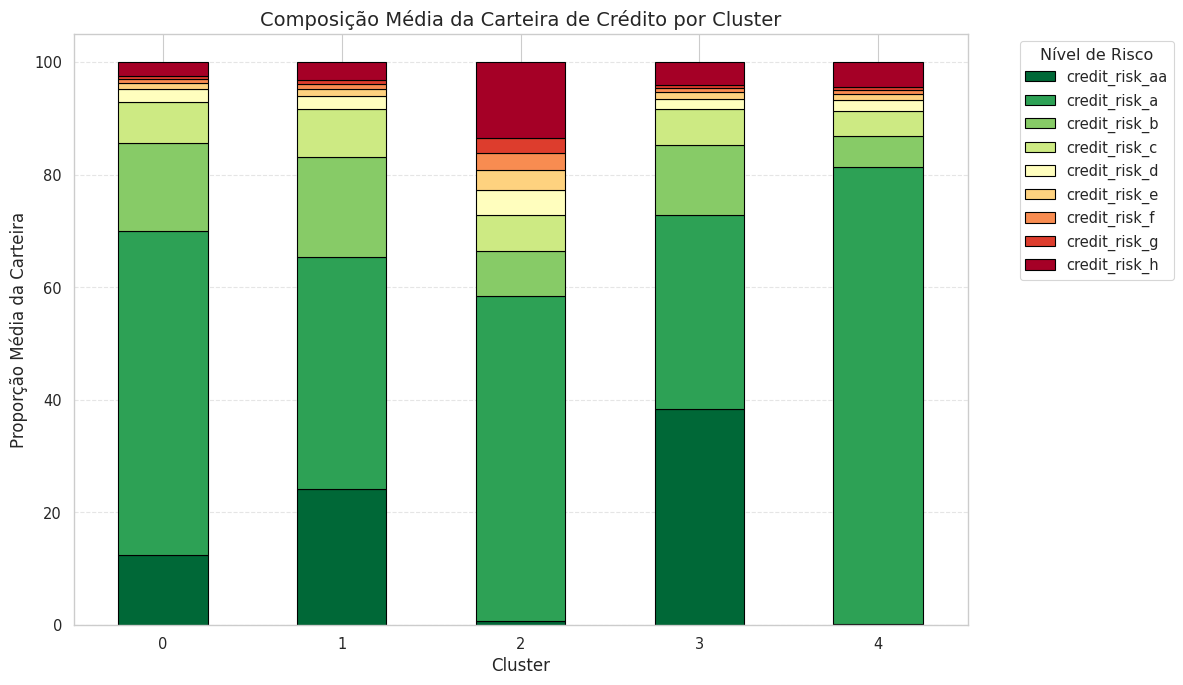

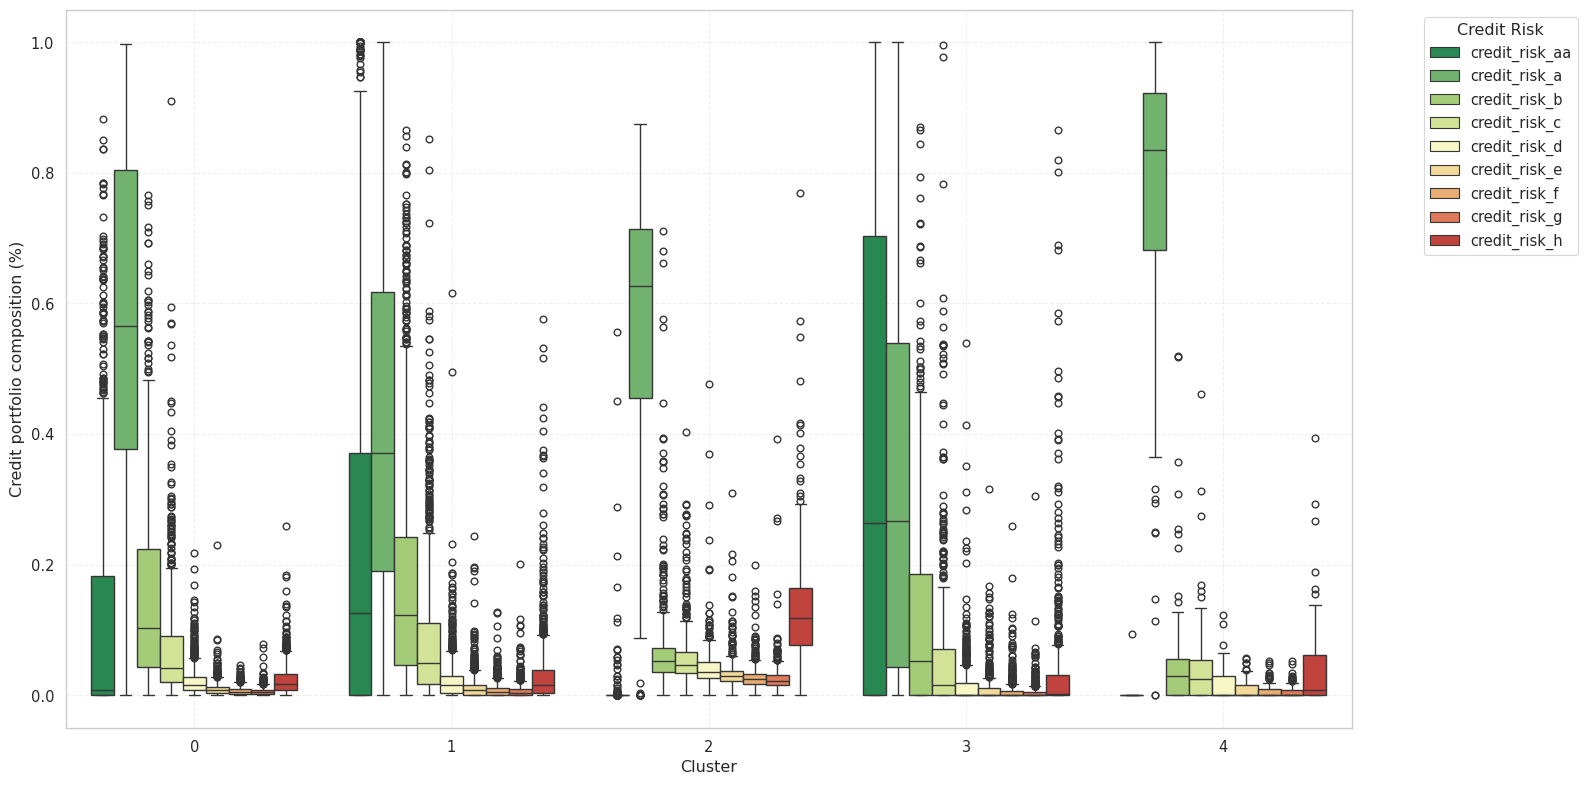

In [15]:
def criar_tabela_operacoes_credito(df_original, df):
    operacoes_de_credito = df_original[['ano', 'cnpj', 'nome', 'taxonomia', 'Cluster', 'compensacao ativa - classificacao da carteira de creditos', 'compensacao ativa - total geral do ativo']].copy()
    niveis = ['aa', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
    colunas_risco_df = [f'compensacao ativa - operacoes de risco nivel {letra}' for letra in niveis]

    df_busca = df[['ano', 'cnpj'] + colunas_risco_df].drop_duplicates(subset=['ano', 'cnpj'])

    operacoes_de_credito = pd.merge(operacoes_de_credito, df_busca, on=['ano', 'cnpj'], how='left')

    colunas_novas = []

    for letra in niveis:
        coluna_risco = f'compensacao ativa - operacoes de risco nivel {letra}'
        nome_nova_coluna = f'credit_risk_{letra}'
        colunas_novas.append(nome_nova_coluna)

        operacoes_de_credito[nome_nova_coluna] = ((operacoes_de_credito['compensacao ativa - total geral do ativo'] * operacoes_de_credito[coluna_risco])/operacoes_de_credito['compensacao ativa - classificacao da carteira de creditos'].replace(0, np.nan)).fillna(0)
        operacoes_de_credito.drop(columns=[coluna_risco], inplace=True)

    operacoes_de_credito['risco_total'] = operacoes_de_credito[colunas_novas].sum(axis=1)


    clusters_unicos = operacoes_de_credito['Cluster'].dropna().unique()
    
    #print("Contagem de Zeros nas Contas de Risco:")
    for cluster in sorted(clusters_unicos):
        # Filtra a tabela apenas para o cluster da vez
        df_filtrado = operacoes_de_credito[operacoes_de_credito['Cluster'] == cluster]
        
        # Conta os zeros APENAS nas colunas de risco (usando a lista salva no passo 2)
        zeros_por_nivel = (df_filtrado[colunas_novas] == 0).sum()
        
        #print(f"\n--- Cluster {cluster} ---")
        #print(zeros_por_nivel)
    
    linhas_todas_zero = (operacoes_de_credito[colunas_novas] == 0).all(axis=1)

    zeros_absolutos_por_cluster = linhas_todas_zero.groupby(operacoes_de_credito['Cluster']).sum()

    #print("\nQuantidade de instituições com ZERO em TODAS as faixas de risco (por Cluster):")
    #print(zeros_absolutos_por_cluster)

    # Criando gráfico de barras para visualizar a distribuição dos riscos por cluster
    colunas_risco = [col for col in operacoes_de_credito.columns if 'credit_risk_' in col]

    perfil_risco_cluster = operacoes_de_credito.groupby('Cluster')[colunas_risco].mean()
    
    #perfil_risco_cluster.drop(columns=['credit_risk_a'], inplace=True) # Risco AA é tão alto que distorce a visualização, então removemos
    perfil_risco_100 = perfil_risco_cluster.div(perfil_risco_cluster.sum(axis=1), axis=0) * 100

    # O colormap 'RdYlGn_r' vai do Verde (risco baixo) ao Vermelho (risco alto)
    perfil_risco_100.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='RdYlGn_r', edgecolor='black')

    plt.title('Composição Média da Carteira de Crédito por Cluster', fontsize=14)
    plt.ylabel('Proporção Média da Carteira', fontsize=12)
    plt.xlabel('Cluster', fontsize=12)

    # Ajuste da legenda
    plt.legend(title='Nível de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0) # Mantém os números dos clusters retos
    plt.tight_layout()
    plt.show()

    # Criando uma visualização de boxplot

    df_melted = operacoes_de_credito.melt(
        id_vars=['Cluster'], 
        value_vars=colunas_risco,
        var_name='Nível de Risco', 
        value_name='Credit portfolio composition (%)'
    )

    plt.figure(figsize=(16, 8))
    sns.boxplot(
        data=df_melted, 
        x='Cluster', 
        y='Credit portfolio composition (%)', 
        hue='Nível de Risco',
        palette='RdYlGn_r'
    )

    #plt.title('Distribution of Credit Risk by Cluster', fontsize=14)
    plt.legend(title='Credit Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return operacoes_de_credito

perfil_credito = criar_tabela_operacoes_credito(df_original, df)    



Tamanho da Amostra C0: 775 | Média: 0.0699
Tamanho da Amostra C2: 109 | Média: 0.0807

=== Teste T de Welch (Paramétrico) ===
Estatística T: 1.0720
P-valor:       1.4298e-01
Conclusão: Não podemos afirmar que o Cluster 4 é maior.

=== Teste U de Mann-Whitney (Não-Paramétrico) ===
Estatística U: 37787.0000
P-valor:       9.6275e-01
Conclusão: Não podemos afirmar que a mediana de 4 é maior.


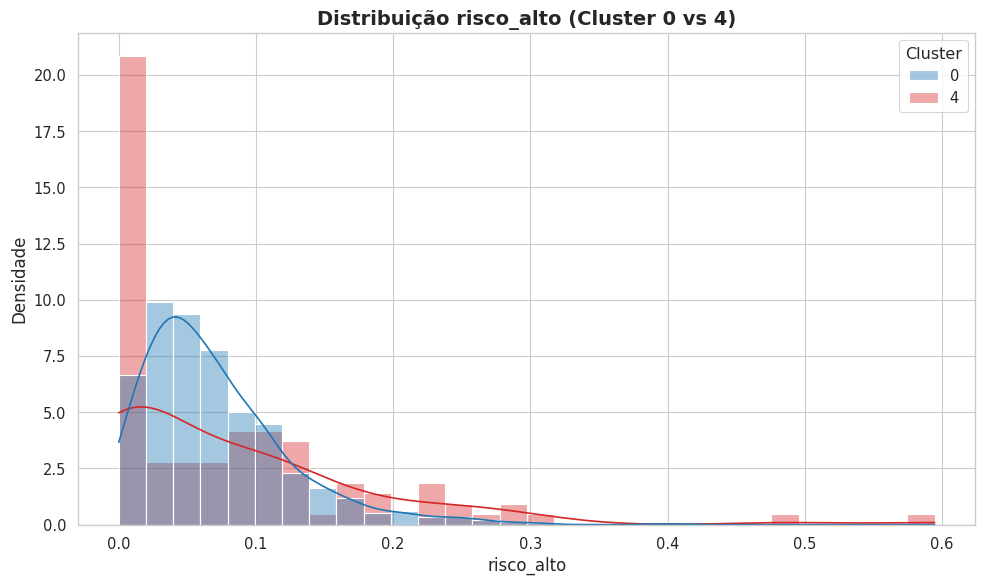

In [16]:
perfil_credito['risco_baixo'] = perfil_credito['credit_risk_aa'] + perfil_credito['credit_risk_a'] + perfil_credito['credit_risk_b'] + perfil_credito['credit_risk_c']

perfil_credito['risco_alto'] = perfil_credito['credit_risk_d'] + perfil_credito['credit_risk_e'] + perfil_credito['credit_risk_f'] + perfil_credito['credit_risk_g'] + perfil_credito['credit_risk_h']

comparar_clusters(perfil_credito, c1=0, c2=4, conta='risco_alto')


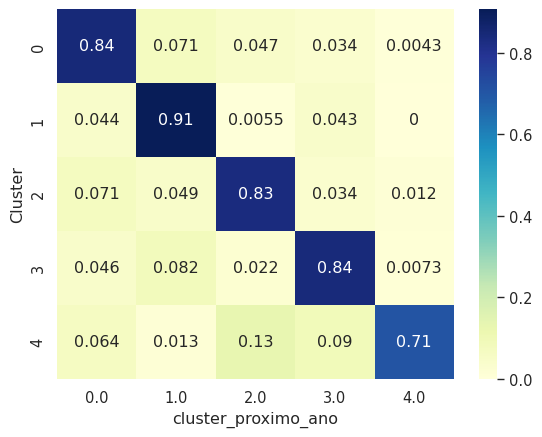

In [17]:
#Criar uma coluna com o cluster do ano seguinte para cada banco

def heatmap_cluster_proximo_ano(df_filtrado):
    df_sorted = df_filtrado.sort_values(['cnpj', 'ano'])
    df_sorted['cluster_proximo_ano'] = df_sorted.groupby('cnpj')['Cluster'].shift(-1)

    # 2. Criar a matriz de contagem/frequência
    matriz_transicao = pd.crosstab(
        df_sorted['Cluster'], 
        df_sorted['cluster_proximo_ano'], 
        normalize='index' # Transforma em porcentagem
    )

    sns.heatmap(matriz_transicao, annot=True, cmap='YlGnBu')

heatmap_cluster_proximo_ano(df_filtrado)

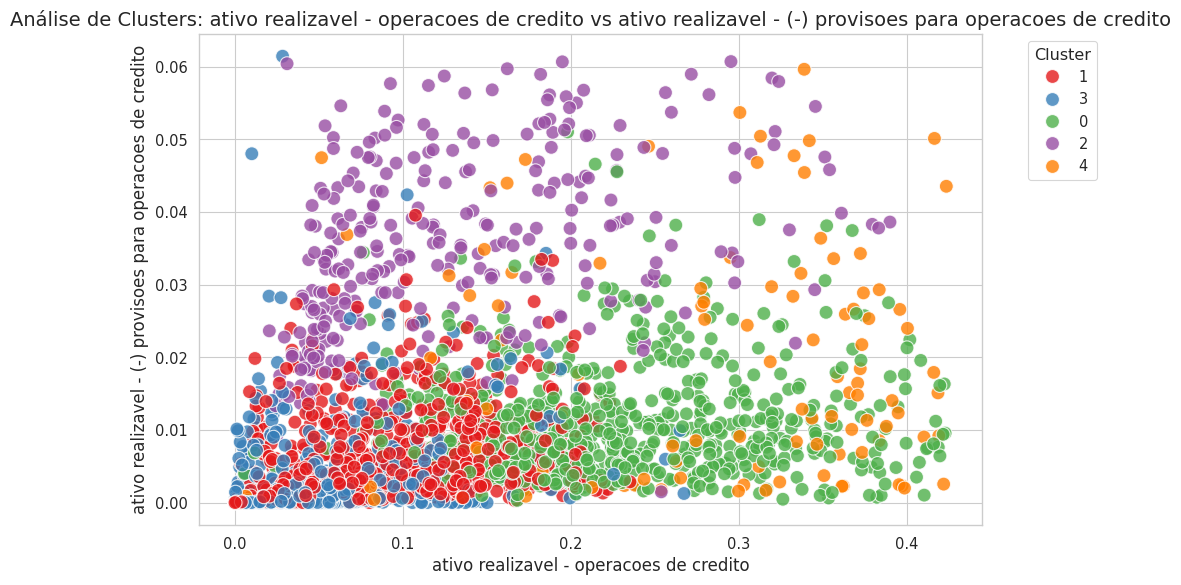

In [18]:
from scipy import stats

def plotar_scatter_clusters(df_filtrado, final_kmeans):
    df_viz = df_filtrado.copy()

    # Adicionamos uma nova coluna com os rótulos dos clusters gerados pelo K-Means
    # Transformamos em string (texto) para que o Seaborn entenda como categorias, não como números contínuos
    df_viz['Cluster'] = final_kmeans.labels_.astype(str)

    # 2. Configuração do Gráfico
    plt.figure(figsize=(10, 6)) # Define o tamanho da figura (largura, altura)

    # 3. Criando o Gráfico de Dispersão (Scatter Plot)
    # Escolha o par de contas do COSIF que você quer cruzar
    conta_x = 'ativo realizavel - operacoes de credito'
    conta_y = 'ativo realizavel - (-) provisoes para operacoes de credito'
    df_viz[conta_y] = df_viz[conta_y].abs() # Inverte os valores para que o gráfico faça mais sentido visualmente

    # Filtra mantendo apenas quem tem Z-score < 3 nos dois eixos
    df_viz = df_viz[
        (np.abs(stats.zscore(df_viz[conta_x])) < 3) &
        (np.abs(stats.zscore(df_viz[conta_y])) < 3)
    ]

    sns.scatterplot(
        data=df_viz, 
        x=conta_x, 
        y=conta_y, 
        hue='Cluster',        # Define a cor baseada na coluna 'Cluster'
        palette='Set1',       # Paleta de cores bem distinta
        s=100,                # Tamanho dos pontos
        alpha=0.8             # Transparência dos pontos (útil se houver sobreposição)
    )

    # 4. Ajustes estéticos (Títulos e Eixos)
    plt.title(f'Análise de Clusters: {conta_x} vs {conta_y}', fontsize=14)
    plt.xlabel(conta_x, fontsize=12)
    plt.ylabel(conta_y, fontsize=12)

    # Move a legenda para fora do gráfico para não cobrir os dados
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Otimiza o layout e exibe o gráfico
    plt.tight_layout()
    plt.show()

plotar_scatter_clusters(df_filtrado, final_kmeans)

In [19]:
import plotly.express as px

def plotar_scatter_matrix_clusters(df_filtrado, final_kmeans, ano_especifico):
    df_viz = df_filtrado.copy()
    df_ano= df_viz[df_viz['ano'] == ano_especifico].copy()
    #df = px.data.X_scaled()
    features = ["ativo realizavel - operacoes de credito", "resultado credor - rendas de operacoes de credito", "resultado credor - receitas operacionais", "resultado devedor - (-) despesas operacionais"]

    fig = px.scatter_matrix(
        df_ano,
        dimensions=features,
        color="Cluster"
    )
    fig.update_traces(
        diagonal_visible=False,
        marker=dict(
            size=4,           # Reduz o tamanho (padrão costuma ser 6 ou 8)
            opacity=0.5,      # 40% de opacidade (permite ver através dos pontos)
            line=dict(width=0) # Remove a borda dos pontos para evitar "borrões" escuros
        )
    )

    fig.update_layout(
        title=f"Matriz de Dispersão - Safra {ano_especifico}",
        hovermode='closest'
    )

    fig.update_traces(diagonal_visible=False)
    fig.show()

#plotar_scatter_matrix_clusters(df_filtrado, final_kmeans, 2017)
#plotar_scatter_matrix_clusters(df_filtrado, final_kmeans, 2018)

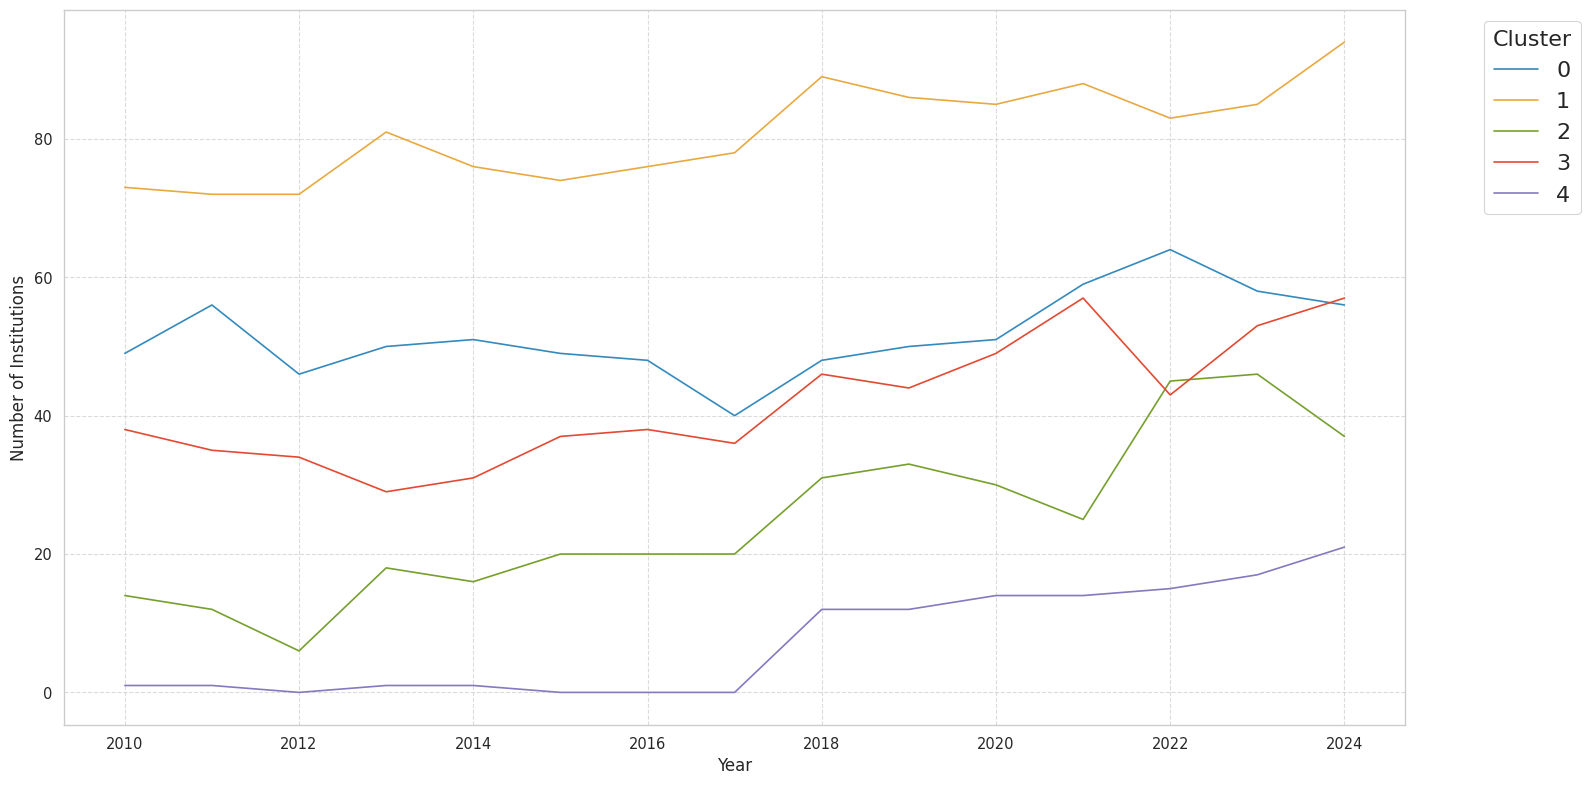

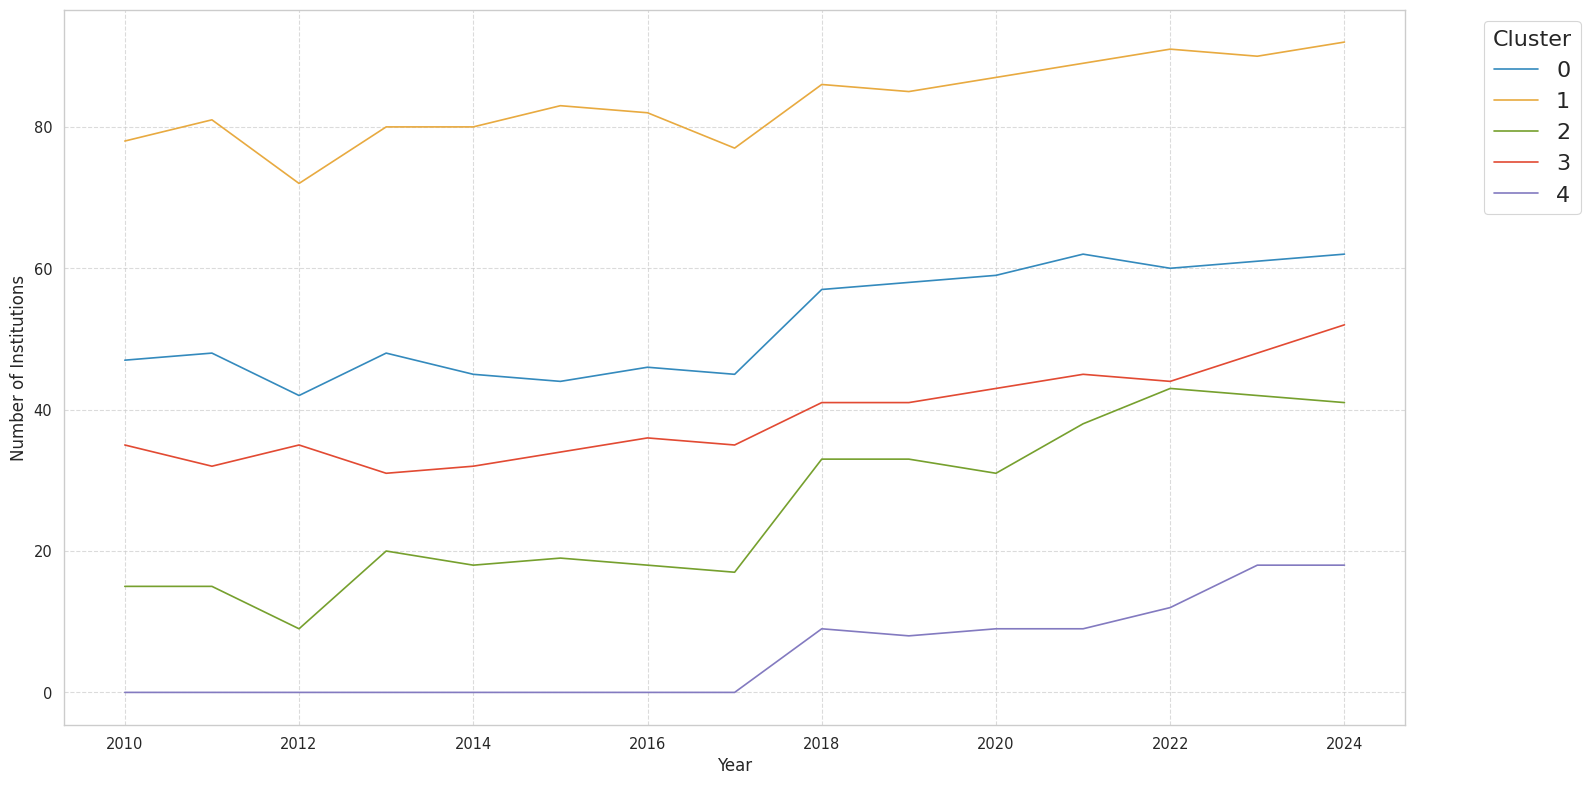

In [20]:
# Ver a evolução da quantidade de bancos em cada cluster por ano
def plotar_evolucao_clusters(df_filtrado):
    cores_padrao = {
        0: '#348ABD',
        1: "#E8AA40",
        2: "#76A02E",  # Verde
        3: '#E24A33',
        4: "#837AC0"   # Amarelo
    }

    evolucao_clusters = df_filtrado.groupby(['ano', 'Cluster']).size().unstack().fillna(0)
    evolucao_clusters.plot(kind='line', color=cores_padrao, stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.ylabel('Number of Institutions', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=16, title_fontsize=16, markerscale=1.5)
    plt.tight_layout()
    plt.show()

df_original_clusters_fixos =  df_original.copy(deep=True)
df_original_clusters_fixos['Cluster'] = df_original_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

plotar_evolucao_clusters(df_filtrado)
plotar_evolucao_clusters(df_original_clusters_fixos)

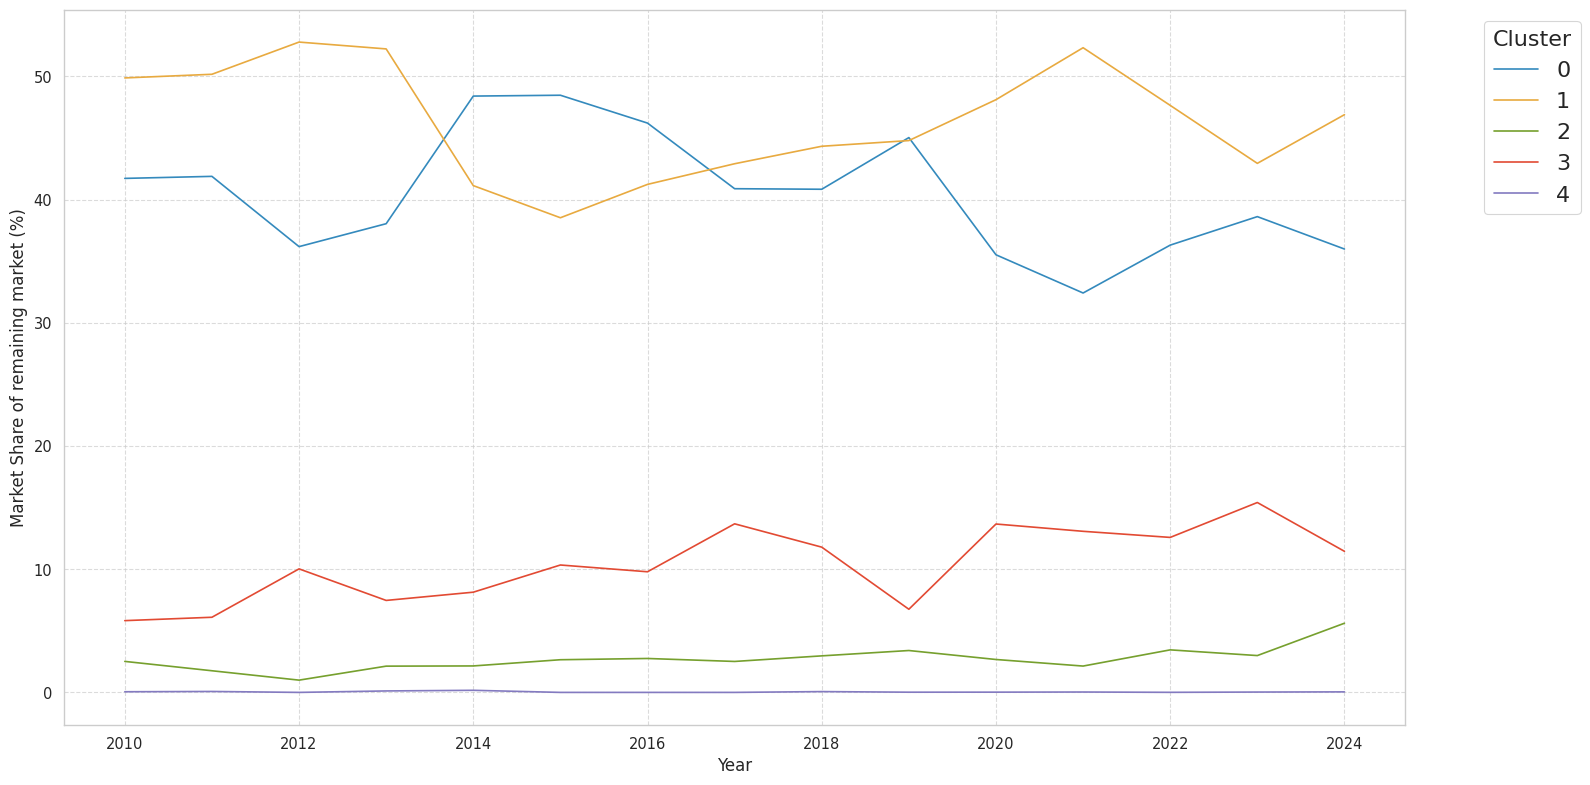

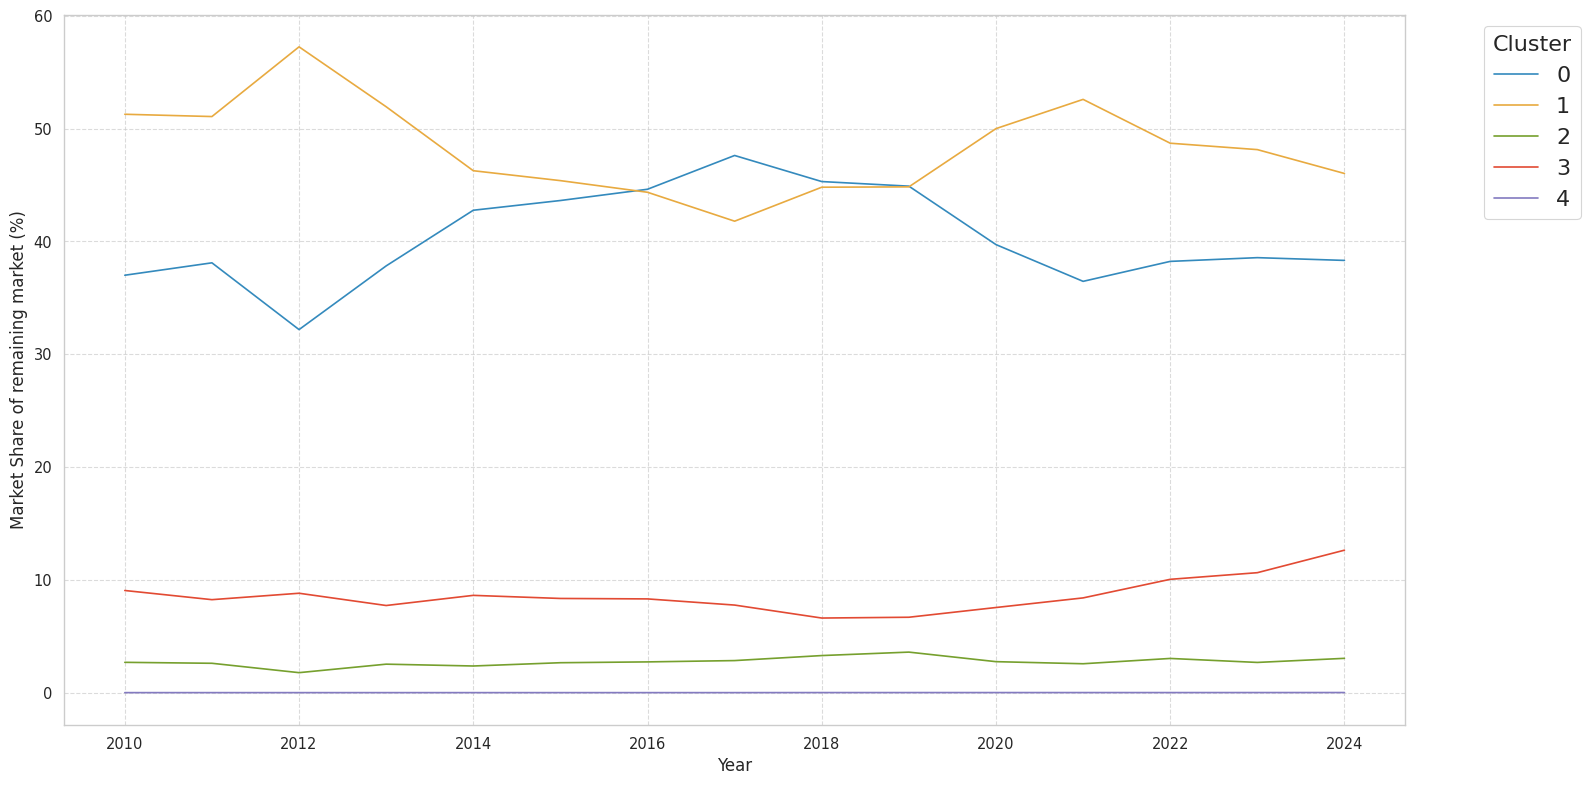

In [21]:
# Calculando o Market Share dos Clusters EXCLUINDO as 6 maiores instituições de cada ano

def calcular_market_share_clusters_excluindo_top5(df_original):
    # 1. Calcular o crédito individual de cada banco (CNPJ) em cada ano
    credito_individual = df_original.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # 2. Encontrar os 6 maiores de cada ano
    # Ordenamos por ano (crescente) e crédito (decrescente), depois pegamos os 6 primeiros
    top6_por_ano = (credito_individual
                    .sort_values(by=['ano', 'ativo realizavel - operacoes de credito'], ascending=[True, False])
                    .groupby('ano')
                    .head(6)[['ano', 'cnpj']]) # Mantemos apenas as chaves de busca (ano e cnpj)

    # 3. Remover os Top 6 da base original
    # O indicator=True cria uma coluna '_merge' que diz se a linha estava nas duas tabelas ('both') ou só na original ('left_only')
    df_sem_top5 = pd.merge(df_original, top6_por_ano, on=['ano', 'cnpj'], how='left', indicator=True)

    # Filtramos para manter apenas os que NÃO estão no Top 6 e apagamos a coluna '_merge'
    df_sem_top5 = df_sem_top5[df_sem_top5['_merge'] == 'left_only'].drop(columns='_merge')

    # 1. Agrupar por ano e cluster usando a base sem os grandes bancos
    share_df = df_sem_top5.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # Renomear para clareza
    share_df.columns = ['ano', 'Cluster', 'credito_cluster']

    # 2. Calcular o NOVO total do mercado para cada ano e fazer a divisão
    share_df['market_share'] = (
        share_df['credito_cluster'] / 
        share_df.groupby('ano')['credito_cluster'].transform('sum')
    )

    # Converter para porcentagem
    share_df['market_share_pct'] = share_df['market_share'] * 100

    # 3. Preparar a tabela matriz (Pivot)
    tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

    cores_padrao = {
        0: '#348ABD',
        1: "#E8AA40",
        2: "#76A02E",  # Verde
        3: '#E24A33',
        4: "#837AC0"   # Amarelo
    }

    tabela_share.T.plot(kind='line', color=cores_padrao, stacked=False, marker='', alpha=1, figsize=(16,8))

    plt.ylabel('Market Share of remaining market (%)', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=16, title_fontsize=16, markerscale=1.5)
    plt.tight_layout() # Evita que a legenda fique cortada ao salvar a imagem
    plt.show()

calcular_market_share_clusters_excluindo_top5(df_original)
calcular_market_share_clusters_excluindo_top5(df_original_clusters_fixos)

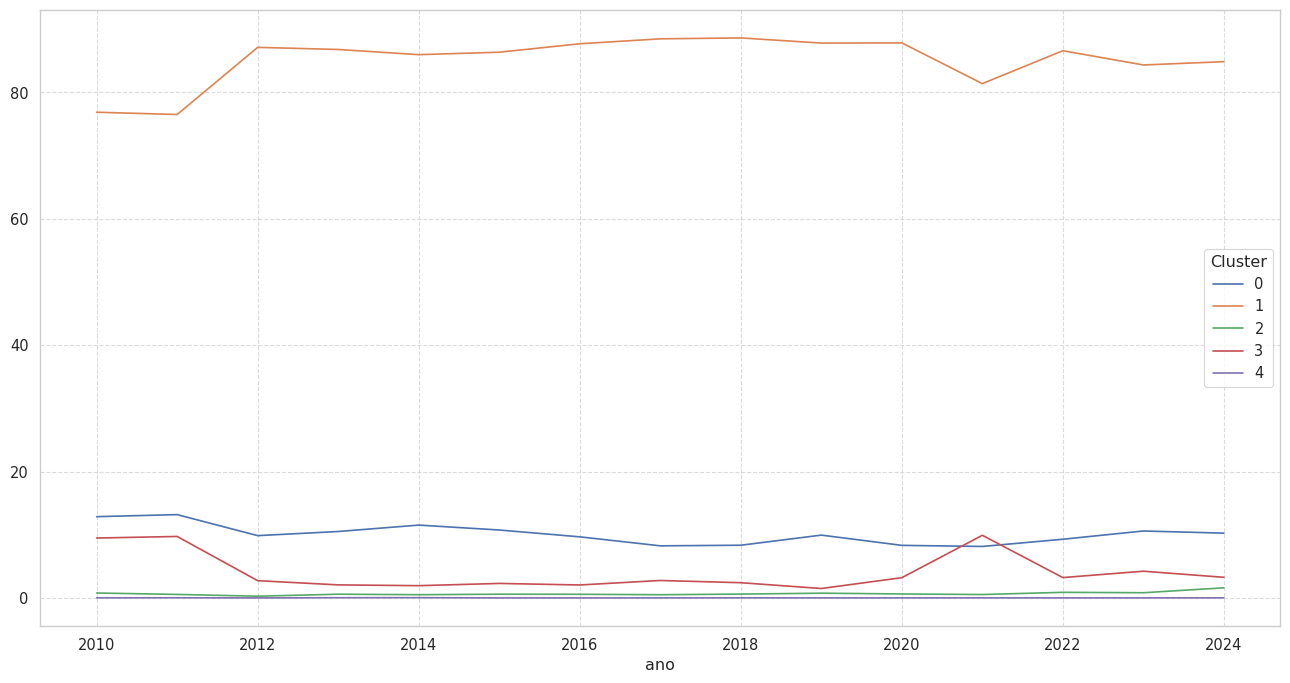

In [22]:
def calcular_market_share(df_original):
    share_individual = df_original.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    share_individual.columns = ['ano', 'cnpj', 'credito_cnpj']

    share_individual['market_share'] = (
        share_individual['credito_cnpj'] / 
        share_individual.groupby('ano')['credito_cnpj'].transform('sum')
    )

    share_individual = pd.merge(share_individual, df_original[['ano','cnpj', 'nome', 'taxonomia', 'Cluster']], on=['ano', 'cnpj'], how='left')

    coluna_c = share_individual.pop('market_share')
    share_individual.insert(6, 'market_share', coluna_c)
    coluna_c = share_individual.pop('credito_cnpj')
    share_individual.insert(6, 'credito_cnpj', coluna_c)

    # 1. Agrupar por ano e cluster para somar o crédito
    share_df = df_original.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # Renomear para clareza
    share_df.columns = ['ano', 'Cluster', 'credito_cluster']

    # 2. Calcular o total do mercado para cada ano e dividir o valor do cluster por esse total
    share_df['market_share'] = (
        share_df['credito_cluster'] / 
        share_df.groupby('ano')['credito_cluster'].transform('sum')
    )

    # Converter para porcentagem para facilitar a leitura
    share_df['market_share_pct'] = share_df['market_share'] * 100

    tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

    tabela_share.T.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.grid(True, linestyle='--', alpha=0.7)
    return share_individual

share_individual = calcular_market_share(df_original)

In [23]:
def plotar_barras_empilhadas_clusters(df_original):
    # 1. Defina as 5 variáveis (contas) que você quer analisar
    # Substitua pelos nomes exatos das colunas no seu DataFrame

    #contas_escolhidas = ['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez', 'ativo realizavel - titulos e valores mobiliarios e instrumentos financeiros derivativos', 'ativo realizavel - operacoes de credito', 'ativo realizavel - outros creditos', 'ativo permanente - ativo permanente']
    #contas_escolhidas = ['resultado credor - rendas de operacoes de credito', 'resultado credor - rendas de aplicacoes interfinanceiras de liquidez', 'resultado credor - rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos', 'resultado credor - rendas de prestacao de servicos', 'resultado credor - outras receitas operacionais']
    contas_escolhidas = ['resultado devedor - (-) despesas de captacao', 'resultado devedor - (-) despesas administrativas', 'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais', 'resultado devedor - (-) outras despesas operacionais', 'resultado devedor - (-) imposto de renda']

    # 2. Agrupe os dados pelo Cluster e calcule a Mediana dessas 5 contas
    # Usamos a mediana para evitar que outliers distorçam a barra
    df_agrupado = df_original[(df_original['Cluster'] != 3)] # Exclui o Cluster 3 e 4, que são outliers extremos
    df_agrupado = df_agrupado.groupby('Cluster')[contas_escolhidas].median().abs()
    df_agrupado = df_agrupado.div(df_agrupado.sum(axis=1), axis=0)

    # 3. Gere o Gráfico de Barras Empilhadas
    # O parâmetro 'stacked=True' é o que faz a mágica de empilhar
    fig, ax = plt.subplots(figsize=(12, 7))
    df_agrupado.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')

    plt.title('Composição dos Clusters pelas 5 Contas Selecionadas', fontsize=16)
    plt.xlabel('Número do Cluster', fontsize=12)
    plt.ylabel('Valor Mediano (Proporção do Ativo Total)', fontsize=12)

    # Rotaciona os números do eixo X para ficarem retos
    plt.xticks(rotation=0) 

    # Move a legenda para fora do gráfico para não tampar as barras
    plt.legend(title='Contas Financeiras', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajusta o layout para a legenda não ser cortada ao salvar
    plt.tight_layout() 

    plt.show()

#plotar_barras_empilhadas_clusters(df_filtrado)
#plotar_barras_empilhadas_clusters(df_original)

Modelo econométrico

In [24]:
# Dados de volatilidade de taxas de juros

def dados_juros():
    conn = sqlite3.connect('dados/banking.db')

    query = """
    SELECT
        *
    FROM
        media_volatilidade_anual
    """

    taxas_termo = pd.read_sql_query(query, conn)

    conn.close()

    taxas_termo['ano'] = taxas_termo['ano'].astype(int)
    return taxas_termo

taxas_termo = dados_juros()

In [25]:

def criar_modelo_final(df_filtrado, df_original, share_individual, taxas_termo):
    model  = df_filtrado[['ano', 'cnpj', 'nome', 'taxonomia','Cluster']].copy()
    df_original = df_original.fillna(0)

    # Net Interest Margin (nim)

    #model['nim'] = 100 * (df[['resultado credor - receitas operacionais', 'resultado devedor - (-) despesas de captacao']].sum(axis=1) / df_original['ativo realizavel - ativo realizavel'])

    model['nim'] = 100 * (df_original['resultado credor - receitas operacionais'] - df_original['resultado devedor - (-) despesas de captacao'].abs()) / df_original['ativo realizavel - ativo realizavel']

    # Market Structure (lerner/herf)

    share_individual['share_quadrado'] = share_individual['market_share'] ** 2
    hhi_anual = share_individual.groupby('ano')['share_quadrado'].sum().reset_index()
    hhi_anual.columns = ['ano', 'hhi']
    model = model.reset_index()

    model = pd.merge(
        model,
        hhi_anual,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None
    model['hhi'] = 100 * model['hhi']

    # Operating Costs (aoc)

    model['aoc'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['compensacao ativa - total geral do ativo'])

    # Degree of risk aversion (riskaver)

    model['riskaver'] = 100 * (df_original['patrimonio liquido - patrimonio liquido'] / df_original['compensacao ativa - total geral do ativo'])

    # Volatility of market interest rates (sd*)

    model = model.reset_index()
    model = pd.merge(
        model,
        taxas_termo,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None

    # Credit Risk (crerisk)

    model['crerisk'] = 100 * (df_original['ativo realizavel - (-) provisoes para operacoes de credito'].abs() / df_original['ativo realizavel - operacoes de credito'])

    # Interaction between credit risk and market risk (sd*crerisk)

    model['sd_3m*crerisk'] = model['sd_annual_3m'] * model['crerisk'] / 100
    model['sd_1ano*crerisk'] = model['sd_annual_1ano'] * model['crerisk'] / 100
    model['sd_2anos*crerisk'] = model['sd_annual_2anos'] * model['crerisk'] / 100
    model['sd_3anos*crerisk'] = model['sd_annual_3anos'] * model['crerisk'] / 100
    model['sd_5anos*crerisk'] = model['sd_annual_5anos'] * model['crerisk'] / 100

    # Average size of operations/volume of loans (size)

    model['size'] = np.log10(df_original['ativo realizavel - operacoes de credito'])

    # Implicit interest payments (iip)

    model['iip'] = 100 * ((df_original['resultado devedor - (-) despesas operacionais'].abs() - df_original['resultado credor - rendas de prestacao de servicos']) / df_original['compensacao ativa - total geral do ativo'])

    # Opportunity costs of bank reserves (reser)

    model['reser'] = 100 * (df[['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez']].sum(axis=1) / df_original['compensacao ativa - total geral do ativo'])

    #model['reser'] = 100 * ((df_original['ativo realizavel - disponibilidades'] + df_original['ativo realizavel - aplicacoes interfinanceiras de liquidez']) / df_original['compensacao ativa - total geral do ativo'])

    # Quality of management (ef)

    model['ef'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['resultado credor - receitas operacionais'])

    # Time dummies
    dummies_tempo = pd.get_dummies(model['ano'], drop_first=True)
    dummies_tempo = dummies_tempo.astype(int)
    model = pd.concat([model, dummies_tempo], axis=1)
    return model



model = criar_modelo_final(df_filtrado, df_original, share_individual, taxas_termo)

In [26]:
# Modelo Time Fixed Effects com clusters fixos

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

# Para evitar que um banco que muda de cluster a cada ano tenha um "Cluster" diferente para cada linha, vamos fixar o cluster do banco pelo seu valor mais frequente (moda)

model_clusters_fixos =  model.copy(deep=True)
model_clusters_fixos['Cluster'] = model_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

def rodar_modelo_panel(model):
#    model['Cluster'] = model.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])
    df_panel = model.set_index(['cnpj', 'ano'])
    # 1. Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    # O dtype=int garante que fique 0 e 1 em vez de True e False
    dummies_cluster = pd.get_dummies(df_panel['Cluster'], prefix='Cluster', dtype=int)

    # Juntamos essas dummies de volta ao nosso painel principal
    df_panel = pd.concat([df_panel, dummies_cluster], axis=1)

    # 2. Definir as Variáveis do Modelo
    # Incluímos as dummies dos Clusters 1, 2, 3 e 5. (O Cluster 0 fica de fora de propósito!)
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_4']

    # Incluímos os controles do balanço do banco
    # NOTA: Não inclua variáveis macro (como 'iip' ou 'sd_annual_3m') aqui, 
    # pois os Efeitos de Tempo já vão controlar tudo isso sozinhos.
    vars_controle = ['hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

    df_panel = df_panel.loc[:, ~df_panel.columns.duplicated()]
    colunas_necessarias = ['nim'] + vars_controle + vars_dummies
    df_panel = df_panel.dropna(subset=colunas_necessarias)

    X = df_panel[vars_controle + vars_dummies]
    X = sm.add_constant(X)
    Y = df_panel['nim']

    # 3. Configurar e Rodar o Modelo
    # entity_effects=False: Fundamental para as dummies de Cluster sobreviverem
    # time_effects=True: Captura a influência macroeconômica específica de cada ano 
    modelo_clusters = PanelOLS(Y, X, entity_effects=False, time_effects=True, drop_absorbed=True)

    # Usamos cluster_entity=True para corrigir a autocorrelação (já que desligamos o entity_effects)
    resultados_clusters = modelo_clusters.fit(cov_type='clustered', cluster_entity=True)

    print(resultados_clusters)

rodar_modelo_panel(model_clusters_fixos)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.5151
Estimator:                   PanelOLS   R-squared (Between):              0.1868
No. Observations:                3096   R-squared (Within):               0.5879
Date:                Tue, Jun 02 2026   R-squared (Overall):              0.5186
Time:                        17:32:02   Log-likelihood                -1.212e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      271.72
Entities:                         359   P-value                           0.0000
Avg Obs:                       8.6240   Distribution:                 F(12,3069)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             18.121
                            

/tmp/ipykernel_1463184/26506956.py:44: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_clusters = modelo_clusters.fit(cov_type='clustered', cluster_entity=True)


In [27]:
# Modelo Two Way Fixed Effects (efeitos fixos de entidade e tempo) com clusters móveis

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

df_panel = model.set_index(['cnpj', 'ano'])
def rodar_modelo_panel(model):
    df_panel = model.set_index(['cnpj', 'ano'])
    # 1. Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    # O dtype=int garante que fique 0 e 1 em vez de True e False
    dummies_cluster = pd.get_dummies(df_panel['Cluster'], prefix='Cluster', dtype=int)

    # Juntamos essas dummies de volta ao nosso painel principal
    df_panel = pd.concat([df_panel, dummies_cluster], axis=1)

    # 2. Definir as Variáveis do Modelo
    # Incluímos as dummies dos Clusters 1, 2, 3 e 5. (O Cluster 0 fica de fora de propósito!)
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_4']

    # Incluímos os controles do balanço do banco
    # NOTA: Não inclua variáveis macro (como 'iip' ou 'sd_annual_3m') aqui, 
    # pois os Efeitos de Tempo já vão controlar tudo isso sozinhos.
    vars_controle = ['hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

    df_panel = df_panel.loc[:, ~df_panel.columns.duplicated()]
    colunas_necessarias = ['nim'] + vars_controle + vars_dummies
    df_panel = df_panel.dropna(subset=colunas_necessarias)

    X = df_panel[vars_controle + vars_dummies]
    X = sm.add_constant(X)
    Y = df_panel['nim']

    # 3. Configurar e Rodar o Modelo
    # entity_effects=False: Fundamental para as dummies de Cluster sobreviverem
    # time_effects=True: Captura a influência macroeconômica específica de cada ano
    modelo_clusters = PanelOLS(Y, X, entity_effects=True, time_effects=True, drop_absorbed=True)

    # Usamos cluster_entity=True para corrigir a autocorrelação (já que desligamos o entity_effects)
    resultados_clusters = modelo_clusters.fit(cov_type='clustered', cluster_entity=True)

    print(resultados_clusters)

rodar_modelo_panel(model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.6007
Estimator:                   PanelOLS   R-squared (Between):             -0.1522
No. Observations:                3096   R-squared (Within):               0.6048
Date:                Tue, Jun 02 2026   R-squared (Overall):              0.4795
Time:                        17:32:02   Log-likelihood                -1.061e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      339.90
Entities:                         359   P-value                           0.0000
Avg Obs:                       8.6240   Distribution:                 F(12,2711)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             11.290
                            

/tmp/ipykernel_1463184/241961747.py:39: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_clusters = modelo_clusters.fit(cov_type='clustered', cluster_entity=True)



=== Evolução Anual dos Coeficientes de Cluster (Base: Cluster 5) ===
      C0_Coef  C0_Pvalor  C1_Coef  C1_Pvalor  C2_Coef  C2_Pvalor  C3_Coef  \
Ano                                                                         
2010   7.8903     0.0949  11.6257     0.0051   6.6281     0.0133   4.6532   
2011   7.7041     0.0313  10.9552     0.0000   5.9304     0.0120   2.0637   
2012   3.5602     0.0517   7.0260     0.0000   3.7894     0.0302   1.1473   
2013   1.6012     0.4284   5.0627     0.0002   2.6689     0.1432   0.4184   
2014   3.8196     0.0992   9.4884     0.0001   2.6463     0.3170   3.5837   
2015   3.1261     0.3380   9.8984     0.0000   3.5771     0.1838   1.7406   
2016  11.2602     0.2490  15.4096     0.0183   4.5170     0.1868  -2.3520   
2017  15.1568     0.2887  15.3160     0.1159   1.2925     0.8398   1.9143   
2018   2.4981     0.4795   5.9895     0.0024   2.7694     0.0797   0.4888   
2019   1.5027     0.5083   5.4311     0.0005   1.7629     0.4136   0.3250   
2020  

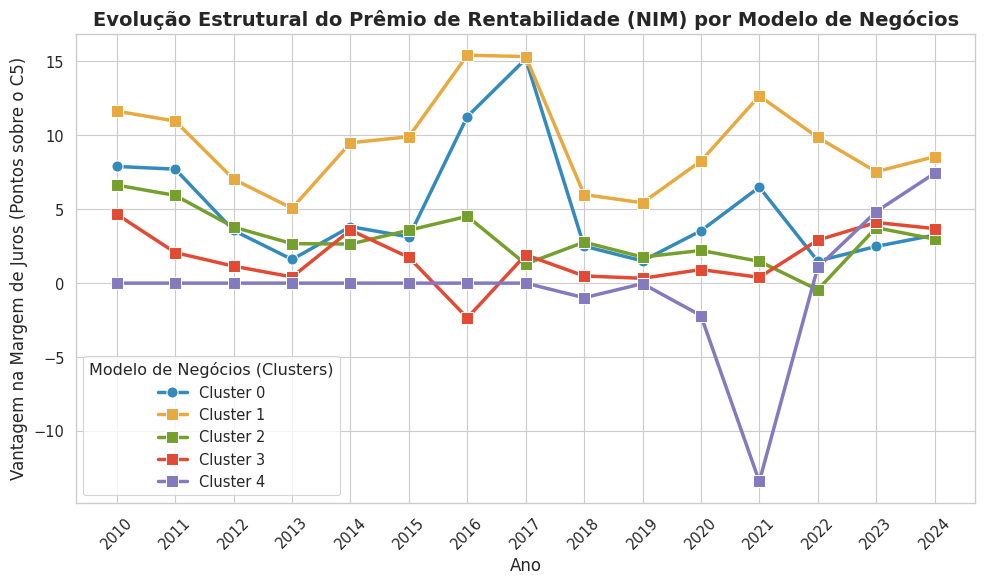

In [35]:
# Fazendo uma regressão para cada ano

import statsmodels.api as sm
import pandas as pd

# A trava do cluster fixo já foi feita por você fora da função (excelente!)
# model_clusters_fixos =  model.copy(deep=True)
# model_clusters_fixos['Cluster'] = model_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

def rodar_regressoes_ano_a_ano(model):
    df_panel = model.set_index(['cnpj', 'ano'])
    
    # 1. Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    dummies_cluster = pd.get_dummies(df_panel['Cluster'], prefix='Cluster', dtype=int)
    df_panel = pd.concat([df_panel, dummies_cluster], axis=1)

    # 2. Definir Variáveis
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4']
    
    # ATENÇÃO: Apenas fundamentos do balanço do banco. 
    # Removidos: 'hhi', 'sd_annual_3m', 'sd_annual_3anos', 'iip', 'reser' e interações macro.
    vars_controle = ['crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

    # Limpeza do DataFrame
    df_panel = df_panel.loc[:, ~df_panel.columns.duplicated()]
    colunas_necessarias = ['nim'] + vars_controle + vars_dummies
    df_panel = df_panel.dropna(subset=colunas_necessarias)

    # Dicionário para guardar a evolução dos coeficientes ao longo dos anos
    resultados_anuais = {}

    # Extrai a lista de anos únicos diretamente do índice do DataFrame
    anos = sorted(df_panel.index.get_level_values('ano').unique())

    # 3. Loop Ano a Ano
    for ano in anos:
        # Fatiar os dados para pegar apenas as instituições presentes neste ano específico
        df_ano = df_panel.xs(ano, level='ano')
        
        X_ano = df_ano[vars_controle + vars_dummies]
        X_ano = sm.add_constant(X_ano)
        Y_ano = df_ano['nim']
        
        try:
            # Roda o OLS usando Erros Padrão Robustos de White (HC3) para lidar com heterocedasticidade
            modelo_ano = sm.OLS(Y_ano, X_ano)
            resultado_ano = modelo_ano.fit(cov_type='HC3')
            
            # Extraindo as estatísticas do Cluster 0 (Varejo) como exemplo principal
            resultados_anuais[ano] = {
                'C0_Coef': resultado_ano.params.get('Cluster_0', None),
                'C0_Pvalor': resultado_ano.pvalues.get('Cluster_0', None),
                'C1_Coef': resultado_ano.params.get('Cluster_1', None),
                'C1_Pvalor': resultado_ano.pvalues.get('Cluster_1', None),
                'C2_Coef': resultado_ano.params.get('Cluster_2', None),
                'C2_Pvalor': resultado_ano.pvalues.get('Cluster_2', None),
                'C3_Coef': resultado_ano.params.get('Cluster_3', None),
                'C3_Pvalor': resultado_ano.pvalues.get('Cluster_3', None),
                'C4_Coef': resultado_ano.params.get('Cluster_4', None),
                'C4_Pvalor': resultado_ano.pvalues.get('Cluster_4', None),
                'R2': resultado_ano.rsquared,
                'N_Bancos': int(resultado_ano.nobs)
            }
        except Exception as e:
            print(f"Erro ao processar o ano {ano}: {e}")

    # 4. Consolidar tudo em uma tabela e retornar
    df_evolucao = pd.DataFrame.from_dict(resultados_anuais, orient='index')
    df_evolucao.index.name = 'Ano'
    
    print("\n=== Evolução Anual dos Coeficientes de Cluster (Base: Cluster 5) ===")
    print(df_evolucao.round(4))
    
    return df_evolucao

def plotar_evolucao_clusters(df_resultado_anual):
    # Configurar o gráfico
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # 2. Criar a figura
    plt.figure(figsize=(10, 6))

    # 3. Plotar a linha do Cluster 0 (Bancos de Varejo)
    # O eixo X é o índice (os anos) e o eixo Y é a coluna dos coeficientes
    sns.lineplot(
        x=df_resultado_anual.index, 
        y=df_resultado_anual['C0_Coef'], 
        marker='o',             # Bolinhas nos pontos exatos dos anos
        label='Cluster 0', 
        color='#348ABD',        # Azul padrão
        linewidth=2.5,
        markersize=8
    )

    sns.lineplot(
        x=df_resultado_anual.index, 
        y=df_resultado_anual['C1_Coef'], 
        marker='s',             # Quadrados (squares) nos pontos para diferenciar
        label='Cluster 1', 
        color='#E8AA40',        # Laranja padrão
        linewidth=2.5,
        markersize=8
    )

    sns.lineplot(
        x=df_resultado_anual.index, 
        y=df_resultado_anual['C2_Coef'], 
        marker='s',             # Quadrados (squares) nos pontos para diferenciar
        label='Cluster 2', 
        color='#76A02E',        # Verde padrão
        linewidth=2.5,
        markersize=8
    )

    sns.lineplot(
        x=df_resultado_anual.index, 
        y=df_resultado_anual['C3_Coef'], 
        marker='s',             # Quadrados (squares) nos pontos para diferenciar
        label='Cluster 3', 
        color='#E24A33',        # Verde padrão
        linewidth=2.5,
        markersize=8
    )

    sns.lineplot(
        x=df_resultado_anual.index, 
        y=df_resultado_anual['C4_Coef'], 
        marker='s',             # Quadrados (squares) nos pontos para diferenciar
        label='Cluster 4', 
        color='#837AC0',        # Roxo padrão
        linewidth=2.5,
        markersize=8
    )

    # 5. Adicionar a "Linha Zero" de referência
    # Essa linha representa o Cluster 5 (A nossa categoria base/Novatos)
    #plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    #plt.text(df_resultado_anual.index[0], 1, 'Base de Comparação (Cluster 5)', color='black', fontsize=10, style='italic')

    # 6. Formatação de Eixos, Título e Legenda
    plt.title('Evolução Estrutural do Prêmio de Rentabilidade (NIM) por Modelo de Negócios', fontsize=14, weight='bold')
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Vantagem na Margem de Juros (Pontos sobre o C5)', fontsize=12)

    # Forçar o eixo X a mostrar todos os anos inteiros da sua base
    plt.xticks(df_resultado_anual.index, rotation=45) 

    plt.legend(title='Modelo de Negócios (Clusters)', loc='best')
    plt.tight_layout()

    # 7. Exibir (ou salvar) o gráfico
    # plt.savefig('evolucao_clusters.png', dpi=300) # Descomente para salvar a imagem em alta resolução
    plt.show()

# Rodando o modelo
df_resultado_anual = rodar_regressoes_ano_a_ano(model_clusters_fixos)
plotar_evolucao_clusters(df_resultado_anual)

In [32]:
# Agora, vamos fazer o mesmo, mas com janelas móveis de 3 anos. Isso vai suavizar um pouco a evolução e mostrar tendências mais claras, já que cada ponto no gráfico vai representar a média dos últimos 3 anos.

def rodar_regressoes_janela_movel(model, tamanho_janela=3):
    df_panel = model.set_index(['cnpj', 'ano'])
    
    # 1. Transformar Clusters e Anos em Dummies
    dummies_cluster = pd.get_dummies(df_panel['Cluster'], prefix='Cluster', dtype=int)
    df_panel = pd.concat([df_panel, dummies_cluster], axis=1)

    # 2. Definir Variáveis
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4']
    vars_controle = ['crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

    # Limpeza do DataFrame
    df_panel = df_panel.loc[:, ~df_panel.columns.duplicated()]
    colunas_necessarias = ['nim'] + vars_controle + vars_dummies
    df_panel = df_panel.dropna(subset=colunas_necessarias)

    # Pegamos todos os anos disponíveis ordenados
    anos_disponiveis = sorted(df_panel.index.get_level_values('ano').unique())
    resultados_janelas = {}

    # 3. Loop das Janelas Móveis
    # Começamos do índice que permite olhar 'tamanho_janela' anos para trás
    # Ex: se tamanho_janela=3, começamos no 3º ano (índice 2)
    for i in range(tamanho_janela - 1, len(anos_disponiveis)):
        # Define os anos que entram nesta janela
        anos_da_janela = anos_disponiveis[i - tamanho_janela + 1 : i + 1]
        ano_ancora = anos_da_janela[-1] # O último ano da janela dará o nome ao ponto no gráfico
        
        # Filtra o DataFrame apenas para os anos da janela
        df_janela = df_panel[df_panel.index.get_level_values('ano').isin(anos_da_janela)].copy()
        
        # Como temos 3 anos juntos, criamos dummies de ano para absorver a macroeconomia do triênio
        # Usamos drop_first=True para evitar colinearidade (dummy base)
        dummies_ano = pd.get_dummies(df_janela.index.get_level_values('ano'), prefix='Ano', drop_first=True, dtype=int).values
        
        X_janela = df_janela[vars_controle + vars_dummies].copy()
        # Adicionamos as dummies de tempo no X manualmente
        for j in range(dummies_ano.shape[1]):
            X_janela[f'Dummy_Ano_{j}'] = dummies_ano[:, j]
            
        X_janela = sm.add_constant(X_janela)
        Y_janela = df_janela['nim']
        
        try:
            # HC1 (erros robustos em painel simples)
            modelo_janela = sm.OLS(Y_janela, X_janela)
            resultado_janela = modelo_janela.fit(cov_type='HC1')
            
            resultados_janelas[ano_ancora] = {
                'C0_Coef': resultado_janela.params.get('Cluster_0', None),
                'C0_Pvalor': resultado_janela.pvalues.get('Cluster_0', None),
                'C1_Coef': resultado_janela.params.get('Cluster_1', None),
                'C1_Pvalor': resultado_janela.pvalues.get('Cluster_1', None),
                'C2_Coef': resultado_janela.params.get('Cluster_2', None),
                'C2_Pvalor': resultado_janela.pvalues.get('Cluster_2', None),
                'C3_Coef': resultado_janela.params.get('Cluster_3', None),
                'C3_Pvalor': resultado_janela.pvalues.get('Cluster_3', None),
                'C4_Coef': resultado_janela.params.get('Cluster_4', None),
                'C4_Pvalor': resultado_janela.pvalues.get('Cluster_4', None),
                'R2': resultado_janela.rsquared,
                'N_Observacoes': int(resultado_janela.nobs)
            }
        except Exception as e:
            print(f"Erro ao processar a janela terminada em {ano_ancora}: {e}")

    df_evolucao_movel = pd.DataFrame.from_dict(resultados_janelas, orient='index')
    df_evolucao_movel.index.name = 'Ano_Fim_Janela'
    
    print(f"\n=== Evolução (Janelas Móveis de {tamanho_janela} Anos) ===")
    return df_evolucao_movel

# Rode o modelo passando a sua base de dados
df_movel = rodar_regressoes_janela_movel(model_clusters_fixos, tamanho_janela=5)
print(df_movel.round(4))


=== Evolução (Janelas Móveis de 5 Anos) ===
                C0_Coef  C0_Pvalor  C1_Coef  C1_Pvalor  C2_Coef  C2_Pvalor  \
Ano_Fim_Janela                                                               
2014             4.3660     0.0009   8.3059        0.0   4.2235     0.0000   
2015             3.5498     0.0021   8.1200        0.0   3.6834     0.0001   
2016             4.1670     0.0523   8.8829        0.0   2.9815     0.0037   
2017             6.5167     0.0574  10.3758        0.0   2.7445     0.0167   
2018             6.8358     0.0680  10.7121        0.0   3.6787     0.0048   
2019             5.6740     0.0804   9.3911        0.0   2.7855     0.0063   
2020             5.8256     0.0645   8.9865        0.0   2.9441     0.0010   
2021             5.5907     0.0411  10.0429        0.0   1.2575     0.3138   
2022             3.0238     0.0115   9.1787        0.0  -0.1916     0.8798   
2023             2.2238     0.0539   8.7912        0.0  -0.3346     0.8250   
2024             2.

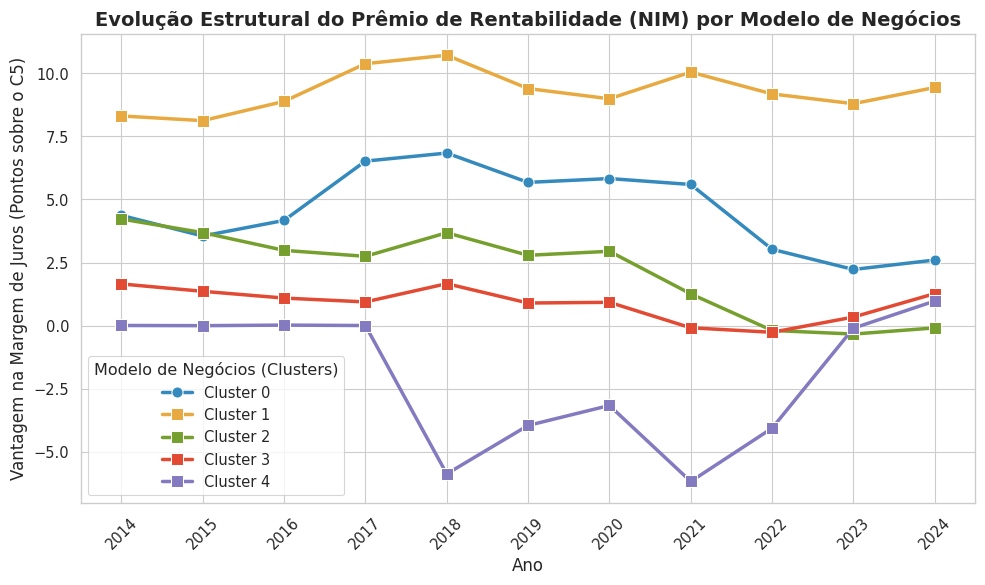

In [36]:
plotar_evolucao_clusters(df_movel)